# 01 · Who should we email? — customer-level uplift ⭐ (Anchor A)

**The business decision.** We have a discount offer and a customer list; contacting one customer costs **€8 all-in** (set with the simulation below — the bar a customer's uplift must clear). Emailing *everyone*
burns margin on people who would have bought anyway, and a discount email can even annoy some
loyal customers into unsubscribing. Emailing *no one* leaves money on the table. So the
question is not "does the email work on average?" but **"for which individual customers does
sending the email actually change what they do?"**

### The one idea this whole notebook rests on

For each customer there are two possible futures: the spend we'd see **if we email them**, and
the spend we'd see **if we don't**. Statisticians call these two futures *potential outcomes*
and write them $Y(1)$ (emailed) and $Y(0)$ (not emailed). The thing we care about is the
**difference** — how much the email *changes* that customer's spend:

$$\tau_i \;=\; Y_i(1) - Y_i(0). \qquad \text{(the customer's individual treatment effect, in €)}$$

We use the Greek letter **τ ("tau")** for this effect throughout. When it depends on the
customer's characteristics $x$ (recency, engagement, …) we write it as a function $\tau(x)$.

The catch — the **"fundamental problem of causal inference"** — is that for any one customer we
only ever get to see *one* of the two futures: we either emailed them or we didn't, never both.
So $\tau_i$ is never directly observed for anybody. Everything that follows is a disciplined way
of *filling in the future we didn't see*.

### Four kinds of customer — and why only the effect tells them apart

Sort customers by what they do in each of the two futures, and four types appear. Notice that
two customers can have the *same observed behaviour* ("bought after being emailed") yet be
completely different types:

| | **buys if emailed** | **doesn't buy if emailed** |
|---|---|---|
| **buys if not emailed** | 🟡 *Sure Thing* — would buy anyway, so τ ≈ 0 (the discount is pure waste) | 🔴 *Sleeping Dog* — the email **backfires**, τ < 0 (reminding them prompts an unsubscribe/return) |
| **doesn't buy if not emailed** | 🟢 *Persuadable* — the email *tips them over*, τ > 0 (**the only type worth paying to reach**) | ⚪ *Lost Cause* — won't buy regardless, τ ≈ 0 |

Only the **Persuadables** are worth a discount. But you cannot identify them from who bought —
a Sure Thing and a Persuadable both "bought after the email." You can only separate them by
estimating the *effect* τ, which is why plain response models (predicting who buys) are the
wrong tool and **uplift models** (predicting whose behaviour *changes*) are the right one.

Targeting is worthwhile **only because τ varies across customers** ("heterogeneity"). If every
customer had the same τ, there'd be nothing to select on — you'd rationally email everyone (if
τ > cost) or no one (if τ < cost). So the entire problem reduces to: **estimate the per-customer
effect $\tau(x)$ well, then turn it into a euro decision that respects how unsure we are.**

### How this notebook is organised

It follows the repo's fixed **7-step contract**, then adds **three depths** a data scientist
needs to defend the number to a skeptic:

- **Steps** — 1 question · 2 simulate a known truth · 3 identify · 4 estimate · 5 validate ·
  6 decide in € · 7 caveats
- **Depth A** estimator bake-off & failure modes · **Depth B** identification rigour & sensitivity ·
  **Depth C** euro policy, value-of-information & test design

> **A note on "Bayesian."** We fit models that return not a single number but a *distribution* of
> plausible values for each effect — a **posterior**. In the narration we never dwell on the
> machinery; a posterior just lets us say *"how sure are we, and does that change what we'd do?"*
> A **90% credible interval** below means "given the data and model, there's a 90% chance the true
> value lies in this range."


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# cmp is this repo's shared package (src/cmp): dgp = data simulators,
# estimators = the models, metrics = validation, policy = the euro decision, plots = styling.
from cmp import dgp, estimators as est, metrics, policy, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"   # FAST=1: quick, coarse posteriors (CI/live reruns)
SEED = 7
COST = 8.0                       # € cost of one discount contact (the number a target must beat)
N    = 900 if FAST else 1600
PROF = dict(draws=140, tune=140, chains=2, m=30) if FAST else dict(draws=600, tune=600, chains=4, m=100)
rng  = np.random.default_rng(SEED)
print(f"FAST={FAST}  N={N}  sampling={PROF}")

FAST=False  N=1600  sampling={'draws': 600, 'tune': 600, 'chains': 4, 'm': 100}


## 2 · Simulate a ground truth (why we start with fake data)

Here is the uncomfortable fact that shapes how we *validate* any causal method: **on real data
we can never check whether the method got the effect right**, because the true effect $\tau_i$ is
never observed for anyone (we only saw one of their two futures). If we just ran a fancy model on
real data and it printed "€6.10", we'd have no way to know if that's right or nonsense.

The way out — used in every notebook here — is **validation-first**: we build a *simulator* that
plants a **known** effect for each customer, generate data from it, and then see whether the
method **recovers the number we planted**. Only after a method passes that test on data where we
know the answer do we trust it on data where we don't. (Section 6b then runs the same pipeline on a
real public dataset, where we can no longer grade recovery but can still make the decision.)

**What the simulator plants.** Each customer gets:

- five features $x$ — `recency` (days since last purchase), `frequency`, `monetary`, `tenure`,
  `engage` (an engagement score);
- a true per-customer effect $\tau(x)$ (in €), deliberately *heterogeneous* — engaged, mid-recency
  customers are **Persuadables** (large positive τ); habitual high-frequency but low-engagement
  customers are **Sleeping Dogs** (τ < 0, the email nudges them to unsubscribe); the rest sit near 0 (τ is continuous, so nobody is *exactly* zero — the Step-2 printout therefore shows only the two signed shares);
- a **selection rule** that decides who got emailed in the past. In the *observational* world we use
  here, marketers historically emailed the already-engaged, recently-active customers — so whether a
  customer was emailed is **tangled up with the kind of customer they are**. That tangling is called
  **confounding**, and it is exactly what makes the naive answer wrong (Step 4 and Depth A show it).

**The data-generating model** — exactly what `dgp.uplift_customers` implements (defaults & seed in
`src/cmp/dgp.py`). Features: $R=$ recency $\sim U(5,330)$, $F=$ frequency $\sim \text{Poisson}(5)$,
$M=$ monetary $\sim U(15,180)$, tenure $\sim U(1,60)$, $E=$ engage $\sim \text{Beta}(2,3)$. With
$\sigma(z)=1/(1+e^{-z})$ the logistic function:

$$
\begin{aligned}
\mu_0(x) &= \max\Big\{0,\; 20 + 1.4\,F + 0.25\,M + 12\,E - 0.03\,R\Big\}\\[2pt]
\tau(x) &= \underbrace{42\, e^{-\left(\frac{R-120}{70}\right)^{2}}\, \sigma(F-3)\, \sigma\big(9(E-0.28)\big)}_{\text{Persuadables: engaged, mid-recency}}
  \;-\; \underbrace{24\, \sigma\big(9(0.22-E)\big)\, \sigma\big(1.2(F-6)\big)}_{\text{Sleeping Dogs: frequent but disengaged}}\\[2pt]
e(x) &= \sigma\Big(1.8\,(E-0.4) + 1.2\,\tfrac{150-R}{150} + 0.15\,(F-5)\Big),
  \qquad T \sim \text{Bernoulli}\big(e(x)\big)\\[2pt]
Y &= \mu_0(x) + \tau(x)\,T + \varepsilon, \qquad \varepsilon \sim \mathcal N(0,\, 8^{2}).
\end{aligned}
$$

Line 1 is the baseline spend if not emailed; line 3 is the historical (observational)
assignment rule. Three things to read off the equations. **(i) The confounding is visible**: engagement and recency
raise the emailing propensity $e(x)$ *and* raise spend through $\mu_0(x)$ — that double role is what
breaks the naive comparison. In the *randomized* regime the third line is replaced by
$e(x)=\tfrac12$ and the confounding vanishes. **(ii) `tenure` is a red herring**: it is drawn but
enters neither $\mu_0$ nor $\tau$, so a good estimator must learn to ignore it. **(iii) Depth B's
hidden confounder** adds an unobserved $U\sim\mathcal N(0,1)$ to both the propensity logit
($+\,a_T U$) and the outcome ($+\,b_Y U$) — the two knobs the sensitivity analysis sweeps.


In [2]:
df = dgp.uplift_customers(n=N, regime="observational", confounder_strength=0.0, cost=COST, seed=SEED)
feat = df.attrs["feature_cols"]          # the five feature column names
X, T, y, tau = df[feat].values, df["T"].values, df["y"].values, df["tau"].values
# T = 1 if emailed else 0 ; y = observed spend (€) ; tau = the PLANTED true effect (known only in sim)

# classify the four uplift types from the known truth (for teaching only — unknown in practice)
# persuadable = the email moves them at all (tau > 0), matching the four-types table above;
# "profitably persuadable" (tau > cost) is the tighter, euro-aware subset reported just below.
types = np.where(tau > 0, "persuadable",
         np.where(tau < 0, "sleeping dog", "sure thing / lost cause"))
print(f"True ATE (average of tau over everyone) = €{tau.mean():.2f}")
print(f"Share historically emailed              = {T.mean():.0%}")
print("\nShare of each uplift type in the base:")
print(pd.Series(types).value_counts(normalize=True).round(2).to_string())
print(f"  (of the base, profitably persuadable at cost €{COST:.0f} — tau > cost: {(tau > COST).mean():.0%})")
df[feat + ['T','y','tau']].head()

True ATE (average of tau over everyone) = €5.95
Share historically emailed              = 48%

Share of each uplift type in the base:
persuadable     0.7
sleeping dog    0.3
  (of the base, profitably persuadable at cost €8 — tau > cost: 30%)


,recency,frequency,monetary,tenure,engage,T,y,tau
0,208.156027,4.0,84.060202,44.320568,0.545720,1.0,45.878520,5.658414
1,296.594485,3.0,48.303531,32.765013,0.518337,1.0,32.005618,-0.008397
2,257.097849,5.0,46.447918,51.242745,0.921777,0.0,45.778013,0.785915
3,78.192337,9.0,90.968991,39.685558,0.411379,0.0,48.419005,18.905056
4,102.554043,4.0,44.561913,11.017535,0.447583,1.0,59.161710,23.398746


The three panels below are the picture to hold in your head for the rest of the notebook:

1. **The planted effect is spread out** (not a single value) — that spread is the *heterogeneity*
   that makes targeting possible, and it straddles both 0 and the €8 cost line.
2. **Persuadables cluster in feature space** — high τ (green) lives at particular recency/engagement
   combinations, which is *why* a model using $x$ can find them.
3. **The confounding, made visible** — the probability of having been emailed *rises with
   engagement*. Emailed and not-emailed customers are therefore **not comparable as-is**; that is the
   problem every method below has to overcome.


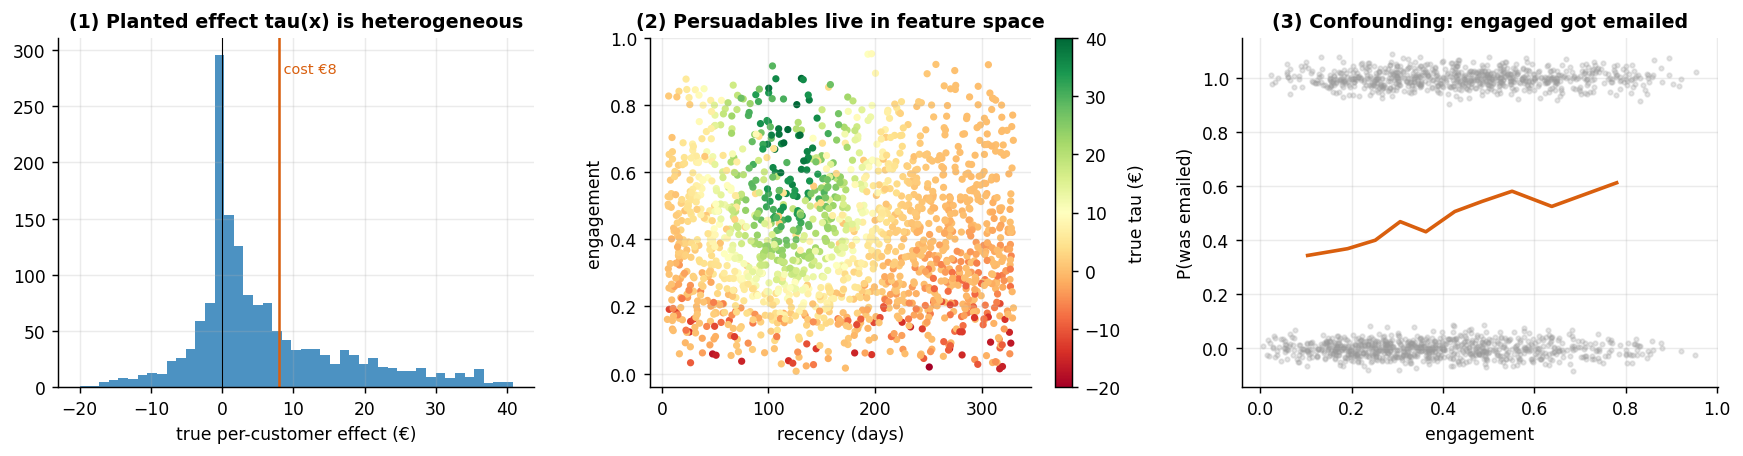

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].hist(tau, bins=45, color=plots.BLUE, alpha=0.85)
ax[0].axvline(COST, color=plots.ORANGE, lw=1.4); ax[0].axvline(0, color="k", lw=0.6)
ax[0].text(COST, ax[0].get_ylim()[1]*0.9, f" cost €{COST:.0f}", fontsize=8, color=plots.ORANGE)
ax[0].set_title("(1) Planted effect tau(x) is heterogeneous"); ax[0].set_xlabel("true per-customer effect (€)")
sc = ax[1].scatter(df.recency, df.engage, c=tau, cmap="RdYlGn", s=9, vmin=-20, vmax=40)
ax[1].set_xlabel("recency (days)"); ax[1].set_ylabel("engagement"); ax[1].set_title("(2) Persuadables live in feature space")
plt.colorbar(sc, ax=ax[1], label="true tau (€)")
ax[2].scatter(df.engage, df["T"] + rng.normal(0, 0.03, N), s=6, alpha=0.25, color=plots.GREY)
bins = pd.qcut(df.engage, 10)
rate = df.groupby(bins, observed=True)["T"].mean()
mid = df.groupby(bins, observed=True)["engage"].mean().values   # decile midpoints (engage is non-uniform)
ax[2].plot(mid, rate.values, color=plots.ORANGE, lw=2)
ax[2].set_xlabel("engagement"); ax[2].set_ylabel("P(was emailed)"); ax[2].set_title("(3) Confounding: engaged got emailed")
fig.tight_layout()

## 3 · Identify — what exactly are we estimating, and when is it even possible?

**"Identification" vs "estimation" — the single most important distinction in causal inference.**
*Identification* asks: *given how the world works, can the effect in principle be recovered from
this data at all?* That is a question about **assumptions**, answered before you fit anything.
*Estimation* is the statistics you do *once identification is granted*. A beautiful model computed
under a false identification assumption is **confidently wrong** — so we keep the two separate.

**The estimand (the precise thing we want).** We climb a ladder of three related quantities:

| quantity | plain meaning | formula |
|---|---|---|
| **ATE** — Average Treatment Effect | "does emailing lift spend *overall*?" | $\mathbb{E}[Y(1)-Y(0)]$ |
| **CATE** — Conditional ATE, $\tau(x)$ | "the effect *for customers like $x$*" → *who* to target | $\mathbb{E}[Y(1)-Y(0)\mid X=x]$ |
| **policy value** | "the € we make from a given targeting rule" | $\mathbb{E}[(\tau(x)-c)\,\mathbb{1}\{\text{we target }x\}]$ |

($\mathbb{E}[\cdot]$ is just "average over customers"; $\mathbb{1}\{\cdot\}$ is 1 when the condition
holds, else 0.) The uplift decision needs all three, but everything rests on the CATE
$\tau(x)=\mu_1(x)-\mu_0(x)$, where $\mu_t(x)=\mathbb{E}[Y\mid T=t, X=x]$ is the *average spend of
emailed ($t{=}1$) or not-emailed ($t{=}0$) customers who look like $x$*.

**The three assumptions that make $\tau(x)$ recoverable** (each is revisited in Depth B):

1. **Unconfoundedness** (a.k.a. *no unmeasured confounders*, "ignorability"): once we condition on the
   measured features $X$, who got emailed is as-good-as-random. Formally
   $\{Y(0),Y(1)\}\perp T \mid X$ ($\perp$ reads "is independent of"; $\mid X$ "once we hold the
   features fixed"). *Guaranteed by design in an A/B test; an assumption otherwise* — and
   the big one, because it can't be checked from data.
2. **Positivity / overlap**: every kind of customer had *some* chance of being emailed and *some* chance
   of not — $0 < e(x) < 1$, where $e(x)=P(T{=}1\mid X{=}x)$ is the **propensity score** (a customer's
   probability of having been emailed). If some group was *always* emailed, we have no comparison for
   them and are extrapolating. Checked in Step 4.
3. **SUTVA**: one customer's email doesn't change another's outcome (no word-of-mouth spillover), and
   there's only one version of "the email."

Under 1–3, the **backdoor adjustment** (or *g-formula*) says $\tau(x)=\mu_1(x)-\mu_0(x)$: comparing
emailed vs not-emailed *within* look-alike customers removes the confounding. The DAG (directed acyclic
graph — a picture of what causes what) shows why. The "backdoor path" email ← features → spend is the
route by which confounding sneaks in; conditioning on the features **blocks** it.


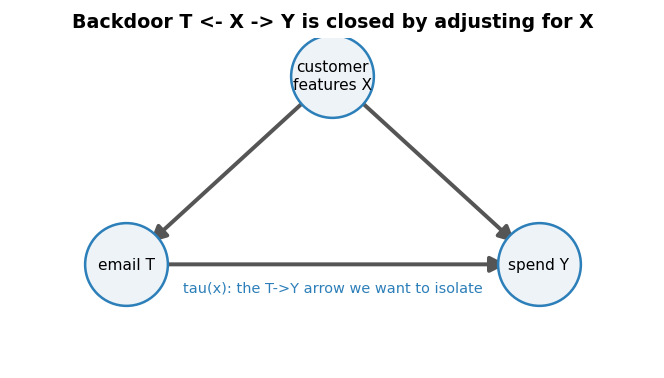

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.0))
pos = {"customer\nfeatures X": (0.5, 1.0), "email T": (0.08, 0.25), "spend Y": (0.92, 0.25)}
edges = [("customer\nfeatures X","email T"),("customer\nfeatures X","spend Y"),("email T","spend Y")]
plots.draw_dag(ax, pos, edges, title="Backdoor T <- X -> Y is closed by adjusting for X")
ax.text(0.5, 0.14, "tau(x): the T->Y arrow we want to isolate", ha="center", fontsize=8, color=plots.BLUE); fig.tight_layout()

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst would do here **without** it. Not a
different analysis: the *same estimands* of §3 — the ATE, then the CATE $\tau(x)$ — under the *same
three assumptions* (unconfoundedness, overlap, SUTVA), estimated with the simplest tools that are
still correct. No likelihood, no prior, no sampler. The causal work lives in the identification
argument, not in the machinery, and this section proves it by doing the whole job without any.

**The ATE, four ways — and the first one is a trap.** The simplest estimator there is, the
**difference in means** ($\bar y_{\text{emailed}} - \bar y_{\text{not emailed}}$, with a Welch
standard error that does not assume the two arms have equal variance), is *exactly right* — under
randomization. Our main scenario is **observational** (§2's third line: the marketers emailed the
engaged and the recently-active), so it is exactly wrong, and it is wrong *confidently*. To make the
point unmissable we run it twice: on our confounded panel, and on a **randomized twin** — the same
customers, the same planted $\tau(x)$, with the assignment rule replaced by a coin flip. Same
estimator, same code, opposite verdicts. **What breaks is the identification, not the arithmetic.**
Then we adjust, two ways:

- **OLS with the features** — $y \sim T + x$ — the workhorse regression adjustment. With a
  heteroskedastic cross-section (spend variance differs by arm and by customer type) the honest
  covariance is **HC1**, not iid: `cov="HC1"`.
- **OLS, Lin-interacted** — $y \sim T \times (x - \bar x)$, i.e. *interact treatment with the
  centred features*. Because the covariates are centred, the coefficient on $T$ is the ATE, and
  because each arm gets its own slopes, the estimator stays consistent for the ATE **even though the
  true $\tau(x)$ is heterogeneous** (Lin 2013). Plain additive OLS silently assumes one common
  effect, so with real heterogeneity it targets a variance-weighted average rather than the ATE —
  a subtle bias the interaction removes for the price of five coefficients.
- **AIPW** — the doubly-robust cross-check of §4, moved here where it belongs: it is a *frequentist*
  estimator with a bootstrap confidence interval and not one prior in sight. Cross-fitted
  (Chernozhukov et al.): the boosted-tree outcome models and the logistic propensity are fit on
  $K-1$ folds and scored out-of-fold, so an adaptive learner never grades its own homework. It is
  consistent if **either** the outcome model or the propensity model is right — see §4's influence
  function $\hat\psi_i$ for the algebra.

All four are graded against the planted ATE, which we happen to know.

In [5]:
from cmp import classical as cl   # the Step-0 toolkit: point estimates + HONEST standard errors

# --- (1) The difference in means: right under randomization, wrong here -------------------------
dm_obs = cl.diff_in_means(y, T)                                    # our OBSERVATIONAL panel
df_rct = dgp.uplift_customers(n=N, regime="randomized", cost=COST, seed=SEED)   # the randomized twin:
dm_rct = cl.diff_in_means(df_rct["y"].values, df_rct["T"].values)  # same customers, same tau, coin-flip T
TRUE_ATE = float(tau.mean())        # the planted truth (df_rct plants the identical tau -- same seed)

# --- (2) Regression adjustment, two specifications, HC1 throughout ------------------------------
d0 = df.copy()
for c in feat:
    d0["c_" + c] = d0[c] - d0[c].mean()              # centred features -> the T coefficient IS the ATE
ate_ols = cl.ols(d0, "y ~ T + " + " + ".join(feat), target="T",
                 cov="HC1", name="ATE (OLS, additive covariates)")
ate_lin = cl.ols(d0, "y ~ T * (" + " + ".join("c_" + c for c in feat) + ")", target="T",
                 cov="HC1", name="ATE (OLS, Lin-interacted)")

# --- (3) AIPW: doubly-robust, cross-fitted, bootstrap CI ----------------------------------------
aipw = est.aipw_ate(X, T, y, seed=SEED, n_boot=200 if FAST else 500)
aipw_cl = cl.Classical("ATE (AIPW, doubly-robust)", aipw["ate"], aipw["se"], aipw["ci90"], 0.10,
                       f"cross-fitted influence function, percentile bootstrap ({len(aipw['boot'])})", N)

def _row(r):
    ok = "YES" if r.ci[0] <= TRUE_ATE <= r.ci[1] else "NO"
    return (f"{r.name:<32}{r.estimate:>8.2f}  [{r.ci[0]:>5.2f}, {r.ci[1]:>5.2f}]{ok:>13}")

print(f"THE PLANTED TRUTH:  ATE = EUR {TRUE_ATE:.2f}   (all figures in EUR)\n")
print(f"{'estimator':<32}{'estimate':>8}{'         90% CI':<16}{'covers truth?':>13}")
for r in (dm_obs, ate_ols, ate_lin, aipw_cl):
    print(_row(r))
print("\n  ...the SAME estimator on the RANDOMIZED twin (identical planted tau):")
print(_row(dm_rct))
print("\n  standard errors, stated not defaulted: Welch (unequal variances) for the two")
print("  differences in means; HC1 heteroskedasticity-robust for both OLS fits; cross-fitted")
print(f"  influence function + {len(aipw['boot'])}-resample percentile bootstrap for AIPW.")
# One panel cannot separate BIAS from LUCK. Re-run all three estimators on fresh panels of
# each regime and average the ERROR against each panel's OWN planted ATE. (dgp draws are
# milliseconds; this is the cheapest honest thing in the notebook.)
NP_ = 6 if FAST else 12
err = {k: [] for k in ("naive · observational", "naive · RANDOMIZED",
                       "OLS Lin-interacted · observational")}
for s_ in range(NP_):
    for regime in ("observational", "randomized"):
        d_ = dgp.uplift_customers(n=N, regime=regime, cost=COST, seed=300 + s_)
        y_, T_, t_ = d_["y"].values, d_["T"].values, d_["tau"].values.mean()
        err[f"naive · {'RANDOMIZED' if regime == 'randomized' else 'observational'}"].append(
            cl.diff_in_means(y_, T_).estimate - t_)
        if regime == "observational":
            for c in feat:
                d_["c_" + c] = d_[c] - d_[c].mean()
            err["OLS Lin-interacted · observational"].append(
                cl.ols(d_, "y ~ T * (" + " + ".join("c_" + c for c in feat) + ")",
                       target="T", cov="HC1").estimate - t_)

print(f"\nBIAS vs LUCK -- the SAME estimators over {NP_} fresh panels of each regime")
print("(mean error against each panel's own planted ATE, in EUR):")
for k, v in err.items():
    v = np.array(v)
    tag = "<- SYSTEMATIC BIAS" if abs(v.mean()) > 2 * v.std() + 0.5 else "<- noise around zero"
    print(f"  {k:<36}{v.mean():>+7.2f}  (sd {v.std():.2f})  {tag}")
print("\nThe naive comparison is not unlucky -- it is WRONG, by roughly the same +EUR 5 every")
print("time, while the identical estimator on RANDOMIZED panels scatters around zero. Nothing")
print("changed but HOW CUSTOMERS WERE SELECTED. The estimator was never the problem; the")
print("identification was. Adjusting for the five features repairs it.")

THE PLANTED TRUTH:  ATE = EUR 5.95   (all figures in EUR)

estimator                       estimate         90% CI covers truth?
ATE (difference in means)          11.37  [ 9.91, 12.83]           NO
ATE (OLS, additive covariates)      6.56  [ 5.62,  7.50]          YES
ATE (OLS, Lin-interacted)           6.39  [ 5.49,  7.29]          YES
ATE (AIPW, doubly-robust)           6.28  [ 5.39,  7.16]          YES

  ...the SAME estimator on the RANDOMIZED twin (identical planted tau):
ATE (difference in means)           5.21  [ 3.79,  6.63]          YES

  standard errors, stated not defaulted: Welch (unequal variances) for the two
  differences in means; HC1 heteroskedasticity-robust for both OLS fits; cross-fitted
  influence function + 500-resample percentile bootstrap for AIPW.

BIAS vs LUCK -- the SAME estimators over 12 fresh panels of each regime
(mean error against each panel's own planted ATE, in EUR):
  naive · observational                 +5.87  (sd 0.66)  <- SYSTEMATIC BIAS
  naiv

**The ATE is not the decision.** §1 said it plainly — "does emailing work on average?" is the wrong
question, because a positive average can hide the Sleeping Dogs the email actively costs us. The
business needs $\tau(x)$, per customer. So: **can the classical arm do heterogeneous effects?**

**Yes, and it is not exotic.** The **T-learner** ("T" = two) is three lines of scikit-learn: fit one
regression of spend on features among the **emailed**, another among the **not emailed**, and subtract
their predictions at every customer's $x$.

$$\hat\tau(x) \;=\; \hat\mu_1(x) \;-\; \hat\mu_0(x), \qquad
\hat\mu_t \;=\; \text{a regression of } y \text{ on } x \text{ fitted on the arm } T=t .$$

That is the backdoor adjustment of §3, done twice. Under the *same* three assumptions it estimates the
*same* $\tau(x)$ the Bayesian model will. No prior, no posterior, no MCMC — and a per-customer number we
can rank, threshold and score on the notebook's **own** metrics (PEHE, correlation, AUUC/Qini). We fit
three versions to separate the *idea* (two arms, subtract) from the *base learner*:

- **T-learner (GBM)** — gradient-boosted trees per arm; the honest classical default, and flexible
  enough for the DGP's Gaussian-bump-times-logistic $\tau(x)$.
- **T-learner (OLS)** — the same recipe with a *linear* model per arm. It is the control experiment for
  functional form: $\tau(x)$ is planted as a smooth non-linear ridge in (recency, engagement) space, and
  a linear model cannot bend to it.
- **S-learner (GBM)** — Depth A's labelled failure mode, in classical clothing: *one* model with
  treatment as an extra column, so the regulariser can shrink the treatment's influence toward zero and
  **flatten** the heterogeneity. Included so the comparison is complete and the failure is *measured*
  rather than asserted.

**The interval is where the classical arm runs out of road — and we measure exactly where.** A T-learner
returns a *point* $\hat\tau(x)$ and nothing else: no per-customer interval falls out of it. The classical
escape hatch is the **nonparametric bootstrap** — resample the customers, refit both arms, repeat — which
does give a band per customer. We compute it (it is cheap) and then grade it honestly against the truth:
how often does the 90% bootstrap interval actually contain that customer's planted $\tau_i$, overall and
in the deciles where the money is? Keep one thing in view while reading the answer: a bootstrap band
describes the **sampling variability of the estimator** — where $\hat\tau(x)$ would land if we redrew the
customer list — and *not* a probability distribution for that customer's effect. §6's rule needs
$P(\tau_i > \text{cost})$. Whether the bootstrap can stand in for it is a claim we test, in euros, in 5x.

In [6]:
from sklearn.ensemble import GradientBoostingRegressor
GBM = dict(n_estimators=200, max_depth=3, learning_rate=0.05)      # one fixed, unremarkable base learner

def t_learner_cl(Xf, Tf, yf, Xs, seed=0):
    """Classical T-learner: fit spend on features SEPARATELY in each arm, subtract. That is all."""
    mu1 = GradientBoostingRegressor(random_state=seed, **GBM).fit(Xf[Tf == 1], yf[Tf == 1])
    mu0 = GradientBoostingRegressor(random_state=seed, **GBM).fit(Xf[Tf == 0], yf[Tf == 0])
    return mu1.predict(Xs) - mu0.predict(Xs)

def s_learner_cl(Xf, Tf, yf, Xs, seed=0):
    """Classical S-learner: ONE model with T as an extra column; CATE = f(x,1) - f(x,0)."""
    m = GradientBoostingRegressor(random_state=seed, **GBM).fit(np.column_stack([Xf, Tf]), yf)
    return (m.predict(np.column_stack([Xs, np.ones(len(Xs))]))
            - m.predict(np.column_stack([Xs, np.zeros(len(Xs))])))

def t_learner_ols(Xf, Tf, yf, Xs):
    """The same T-learner recipe with a LINEAR model per arm -- the functional-form control."""
    b = [np.linalg.lstsq(np.column_stack([np.ones((Tf == t).sum()), Xf[Tf == t]]),
                         yf[Tf == t], rcond=None)[0] for t in (0, 1)]
    return np.column_stack([np.ones(len(Xs)), Xs]) @ (b[1] - b[0])

cl_t = t_learner_cl(X, T, y, X, seed=SEED)      # the classical per-customer CATE we carry into 5x
cl_s = s_learner_cl(X, T, y, X, seed=SEED)
cl_o = t_learner_ols(X, T, y, X)

print("CLASSICAL CATE -- graded on THIS notebook's own metrics (cmp.metrics), vs the")
print("planted tau(x).  PEHE = RMSE against the true tau, in EUR (lower is better);")
print("AUUC: 1.0 = the oracle's ranking, 0 = no better than random.\n")
print(f"{'estimator':<22}{'ATE':>8}{'PEHE':>8}{'corr':>7}{'AUUC':>7}")
for nm, c in (("T-learner (GBM)", cl_t), ("S-learner (GBM)", cl_s), ("T-learner (OLS)", cl_o)):
    print(f"{nm:<22}{c.mean():>7.2f}{metrics.pehe(c[None, :], tau):>8.2f}"
          f"{metrics.corr_with_truth(c, tau):>7.2f}{metrics.auuc(c, tau):>7.2f}")
print(f"\n  -> No Bayes anywhere, and the GBM T-learner already ranks customers at AUUC "
      f"{metrics.auuc(cl_t, tau):.2f} of\n"
      f"     the oracle. Functional form, not philosophy, is what costs you: the same recipe\n"
      f"     with a LINEAR learner per arm drops to AUUC {metrics.auuc(cl_o, tau):.2f}.\n"
      f"     The S-learner loses on magnitudes (PEHE {metrics.pehe(cl_s[None,:], tau):.2f} vs "
      f"{metrics.pehe(cl_t[None,:], tau):.2f}): its shared treatment\n"
      f"     column is regularised toward zero, so it flattens tau(x). Depth A repeats the\n"
      f"     bake-off with BART base learners, where the flattening is severe enough to wreck\n"
      f"     the RANKING too -- the failure mode is real, and its severity is a property of the\n"
      f"     base learner, not of the letter 'S'.")

# --- The limitation, MEASURED: a bootstrap band per customer, and what it does (not) cover -------
B = 40 if FAST else 200                          # bootstrap replicates (refits BOTH arms each time)
rng_b = np.random.default_rng(SEED)
tboot = np.empty((B, N))
for b in range(B):
    ix = rng_b.integers(0, N, N)                 # resample customers with replacement, refit, re-score
    tboot[b] = t_learner_cl(X[ix], T[ix], y[ix], X, seed=SEED + b)
cl_cov, cl_by_dec = metrics.interval_coverage(tboot, tau, level=0.90, by_decile=True)

print(f"\nBOOTSTRAP INTERVALS for the T-learner ({B} resamples), graded against the planted tau_i:")
print(f"  overall 90% coverage {cl_cov:.0%} (nominal 90%)   ·   mean width EUR "
      f"{metrics.sharpness(tboot):.1f}")
print(f"  TOP decile of true effect (where the money is): {cl_by_dec.iloc[-1]:.0%}"
      f"   ·   BOTTOM decile (sleeping dogs): {cl_by_dec.iloc[0]:.0%}")
print("  -> broadly honest in the middle, fraying at BOTH extremes -- exactly where a")
print("     targeting rule lives. And it is the wrong object: a band around the ESTIMATOR,")
print("     not a belief about tau_i.\n")
print(aipw_cl.cannot_say())

CLASSICAL CATE -- graded on THIS notebook's own metrics (cmp.metrics), vs the
planted tau(x).  PEHE = RMSE against the true tau, in EUR (lower is better);
AUUC: 1.0 = the oracle's ranking, 0 = no better than random.

estimator                  ATE    PEHE   corr   AUUC
T-learner (GBM)          6.52    5.21   0.89   0.89
S-learner (GBM)          6.11    6.44   0.85   0.89
T-learner (OLS)          6.39    8.79   0.56   0.62

  -> No Bayes anywhere, and the GBM T-learner already ranks customers at AUUC 0.89 of
     the oracle. Functional form, not philosophy, is what costs you: the same recipe
     with a LINEAR learner per arm drops to AUUC 0.62.
     The S-learner loses on magnitudes (PEHE 6.44 vs 5.21): its shared treatment
     column is regularised toward zero, so it flattens tau(x). Depth A repeats the
     bake-off with BART base learners, where the flattening is severe enough to wreck
     the RANKING too -- the failure mode is real, and its severity is a property of the
     base


BOOTSTRAP INTERVALS for the T-learner (200 resamples), graded against the planted tau_i:
  overall 90% coverage 86% (nominal 90%)   ·   mean width EUR 13.0
  TOP decile of true effect (where the money is): 78%   ·   BOTTOM decile (sleeping dogs): 78%
  -> broadly honest in the middle, fraying at BOTH extremes -- exactly where a
     targeting rule lives. And it is the wrong object: a band around the ESTIMATOR,
     not a belief about tau_i.

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect lies inside it. It is a property of the *procedure* — 90% of intervals built this way would cover the truth across repeated samples. This interval either contains the truth or it does not. To get a probability *about the effect itself* — the thing a go/no-go rule like P(lift > cost) >= 0.9 actually needs — you need a posterior. That is what the Bayesian section adds.


**Read-out — the classical answer, in business terms.** Printed above, in order:

1. **The naive comparison is a trap, and the trap is identification.** "Emailed customers spent €11-ish
   more" nearly *doubles* the true €6-ish effect, with a tight interval that **misses the truth
   entirely** — the textbook shape of *precisely wrong*. And the **bias-vs-luck** block settles that this
   is not one unlucky draw: averaged over fresh panels, the naive estimator is off by roughly the same
   +€5 *every time*, while the **identical estimator on randomized panels scatters around zero**. (Any
   single randomized twin can still miss its interval by chance — that is what a 90% interval means —
   which is exactly why we grade the *mean error over panels*, not one draw.) Nothing changed but who
   got picked: the failure is in the identification, not the arithmetic.
2. **Adjustment repairs it, and the three adjusted estimators agree.** Additive OLS, Lin-interacted OLS
   and cross-fitted AIPW land within a euro of each other and of the planted ATE, each with the truth
   inside its 90% interval. Three different bias-correction strategies (regression, regression with
   arm-specific slopes, doubly-robust) converging on one number is a *credibility* signal, and we bank
   it before any prior is written down.
3. **Heterogeneous effects do not require Bayes.** The classical T-learner delivers a per-customer
   $\hat\tau(x)$ that ranks customers at the AUUC printed above — a large fraction of the oracle's
   ranking, from two scikit-learn fits and a subtraction. Anyone who tells you that you *need* a
   posterior to do uplift is selling something. What you need is (i) the identification argument of §3
   and (ii) a base learner flexible enough for the true $\tau(x)$ — and the OLS row shows that the
   second is not free: the same recipe with a linear learner collapses.

**This is the honest baseline the Bayesian section must now beat.** Not a strawman: a competent,
correctly-standard-errored, doubly-robust-cross-checked, oracle-graded classical analysis, which has
already produced (a) the right ATE, (b) a per-customer effect, and (c) a defensible ranking. Section 5x
will hold §4's posterior to exactly this bar and report what it does and does not buy.

**The guardrail — what those confidence intervals do *not* say** (printed above, in the words this
cookbook uses in every notebook): a 90% CI is **not** a 90% probability that the true effect is inside
it. It is a property of the *procedure* — 90% of intervals built this way cover the truth across
repeated samples — and this one either covers it or it does not. The same applies, exactly, to the
bootstrap band we just put around each customer's $\hat\tau(x)$: resampling the customer list
approximates *the sampling distribution of the T-learner*, so the band is centred on $\hat\tau(x)$, not
on $\tau_i$, and every replicate refits the same learner on the same information — a systematically
shrunken estimate stays shrunken in all 200 of them, and the band tightens **around the wrong value**
without a hint of complaint. That is visible in the printout: coverage sags at both extremes of the true
effect, worst where $\tau_i$ is largest.

And §6's rule is $P(\tau_i > \text{cost}) \ge 0.8$ — a probability **about this customer's effect**,
one number per customer, feeding a threshold that a CMO can dial. The classical arm has no such object.
It can offer the bootstrap *exceedance share* — the fraction of resamples in which $\hat\tau^{*}(x)$
happened to exceed €8 — which looks like a probability, is not one, and carries no guarantee of
behaving like one. Whether that distinction costs real money, or is a philosopher's quibble, is not
something we will assert. **5x measures it, in euros.**

## 4 · Estimate — check overlap first, then fit two independent ways

**Discipline: look at overlap *before* estimating.** Adjustment can only compare emailed vs
not-emailed customers where *both* actually exist. If, at some feature combination, everyone was
emailed, there is no control to compare against and the model is silently extrapolating. So we first
plot the **propensity score $e(x)$** by arm (emailed vs not); healthy overlap means the two histograms
cover the same range, with few customers stuck at 0 or 1.


Overlap is adequate — only 0 of 1600 customers fall in the <0.05 / >0.95 tails.


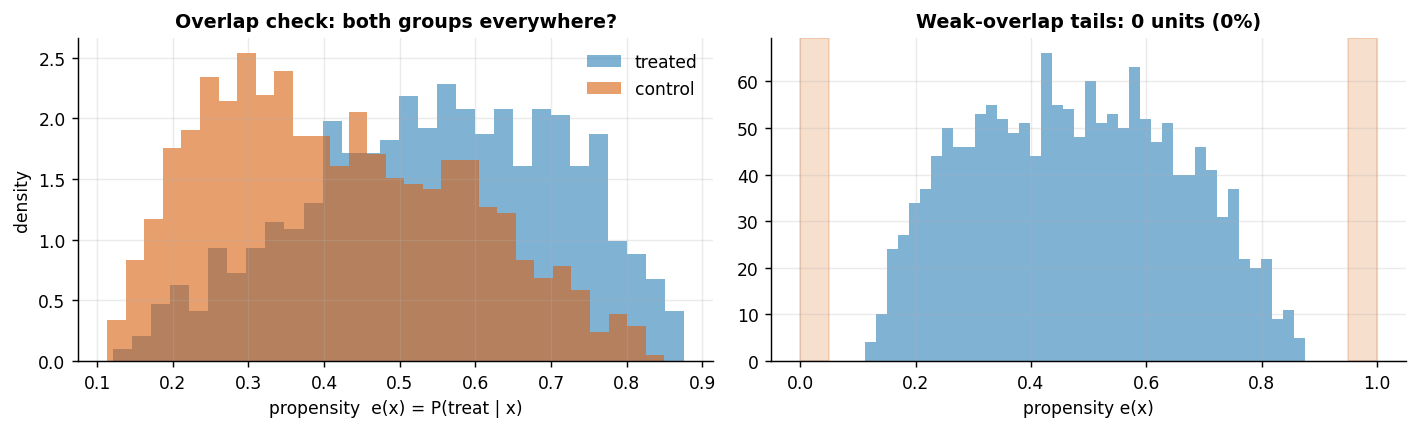

In [7]:
phat = est.propensity_scores(X, T, seed=SEED)     # estimated e(x) = P(emailed | features), via logistic regression
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
plots.overlap_plot(ax[0], phat, T.astype(bool))
weak = (phat < 0.05) | (phat > 0.95)              # customers in the no-overlap tails
ax[1].hist(phat, bins=40, color=plots.BLUE, alpha=0.6); ax[1].axvspan(0, 0.05, color=plots.ORANGE, alpha=0.2)
ax[1].axvspan(0.95, 1.0, color=plots.ORANGE, alpha=0.2)
ax[1].set_xlabel("propensity e(x)"); ax[1].set_title(f"Weak-overlap tails: {weak.sum()} units ({weak.mean():.0%})")
fig.tight_layout()
print(f"Overlap is adequate — only {weak.sum()} of {N} customers fall in the <0.05 / >0.95 tails.")

**Now the estimators.** We fit the effect two completely different ways and check they agree —
agreement across independent methods is our first credibility signal.

- **BCF — Bayesian Causal Forest** (our primary CATE model). Under the hood it's **BART** (Bayesian
  Additive Regression Trees — a flexible sum-of-trees model that needs no functional-form guesswork and
  returns a posterior). BCF is a causal-tuned BART with two tricks: it feeds the estimated propensity
  $e(x)$ into the model so *targeted-selection confounding* is absorbed (**targeted selection** is our
  data's specific confounding pattern: marketers emailed customers *because* they looked likely to spend,
  so the propensity $e(x)$ and the baseline spend $\mu_0(x)$ move together — feeding $\hat e(x)$ in lets
  the model soak up exactly that overlap, which is why BCF beats a plain T-learner precisely here, and
  only here, per Step 7's caveat), and it puts **fewer trees on the treatment
  surface** than on the baseline surface (a weak, tree-count form of BCF's shrinkage-toward-homogeneity
  prior), so the model only reports heterogeneity when the data really support it (rather than reading
  noise as signal). Output: a posterior array of shape
  `(draws, customers)` — one plausible $\tau(x)$ curve per posterior draw.
- **AIPW — Augmented Inverse-Propensity Weighting** (a cross-check on the *average*) — **already fitted, back
  in Step 0**, because it is a purely classical estimator: no prior, no sampler, a bootstrap confidence
  interval. We do not refit it here; we simply hold BCF's posterior-mean ATE up against it. It's
  **doubly-robust**: it combines an outcome model (gradient-boosted trees here) and a propensity model, and is
  correct if *either one* is right. It's a **methodologically different** cross-check (a different outcome
  model plus explicit propensity weighting), so agreement is reassuring though not fully independent.

**The fitted model (BCF), in symbols.** With $\hat e(x)$ the propensity estimated above:

$$
\begin{aligned}
y_i &\sim \mathcal N\big(\mu_i,\; \sigma^{2}\big), \qquad
\mu_i = f_{\text{prog}}\big(x_i,\, \hat e(x_i)\big) \;+\; f_{\tau}(x_i)\, T_i, \qquad
\sigma \sim \text{HalfNormal}(15),\\[2pt]
f_{\text{prog}} &\sim \text{BART}(m \text{ trees}), \qquad
f_{\tau} \sim \text{BART}(m/2 \text{ trees}),
\end{aligned}
$$

where $f_{\text{prog}}$ is the prognostic surface (baseline spend as a flexible function of the
features *and* the propensity — feeding $\hat e$ in is the trick that absorbs targeted-selection
confounding) and $f_{\tau}$ is the treatment surface, whose posterior **is** the CATE:
$\hat\tau(x) = f_{\tau}(x)$. Halving the tree count on $f_{\tau}$ is the
shrink-toward-homogeneity prior from the bullet above, in its concrete form. (The $\text{HalfNormal}(15)$
on $\sigma$ is just a mild prior keeping the noise sd positive and around the tens-of-euros scale —
nothing hinges on the exact 15.)

**The cross-check (AIPW), in symbols.** AIPW averages one *influence-function* score $\hat\psi_i$ per customer — think of it as each customer's
individual contribution to the average effect, engineered so that errors in either model wash out (see
below) — built from an outcome model $\hat\mu_t(x)$ (predicted spend under treatment $t \in \{0,1\}$) and
the propensity $\hat e(x)$:

$$
\hat\psi_i \;=\; \underbrace{\hat\mu_1(x_i)-\hat\mu_0(x_i)}_{\text{outcome-model guess}}
\;+\; \underbrace{\frac{T_i\,\big(y_i-\hat\mu_1(x_i)\big)}{\hat e(x_i)}
\;-\; \frac{(1-T_i)\,\big(y_i-\hat\mu_0(x_i)\big)}{1-\hat e(x_i)}}_{\text{inverse-propensity-weighted residual corrections}},
\qquad
\widehat{\text{ATE}} \;=\; \frac{1}{n}\sum_{i=1}^{n} \hat\psi_i .
$$

This equation is *why* "doubly robust" is more than a slogan: if the outcome models are right, the
residuals $y_i - \hat\mu_{T_i}(x_i)$ are mean-zero and the correction terms vanish on average,
leaving the correct first term; if instead the propensity is right, the inverse-weighted residuals
exactly repair whatever bias the outcome models leave behind. Either model correct suffices — only
both wrong breaks the estimator.

> **The pymc-bart gotcha, baked in.** Scoring BART counterfactuals ("what would this customer have spent
> under the *other* treatment?") silently returns *frozen training predictions* — every effect exactly 0
> — unless the tree node is resampled. `cmp.estimators` always does this correctly, and a unit test
> asserts non-zero recovered effects, so you never hit the trap.

> **Did the sampler converge? (the check behind every posterior in this cookbook).** All the Bayesian
> fits here draw posterior samples with **MCMC** (Markov-chain Monte Carlo — the standard algorithm for drawing
> from a posterior), and a posterior is only trustworthy if the sampler
> actually converged. Three standard diagnostics, in plain terms:
>
> - **R-hat** — run several independent chains and compare them: if they disagree about where the
>   posterior is, they haven't converged. R-hat ≈ 1.00 is good; above ~1.01 means keep sampling (or fix
>   the model). One honest exception, applied in the very next cell: BART is fitted with the
>   particle-Gibbs **PGBART** sampler, and scalars coupled to its tree sums (like the
>   observation-noise sd we monitor) routinely sit at r-hat ≈ 1.01–1.02 in FULL runs even when the
>   fit is fine — and, unlike pure NUTS, raising draws grinds that down only slowly.
>   So for the BART-based fits we read **≤ 1.01 as a clean pass, 1.01–1.02 as *tolerated*** (with the
>   8-seed stability sweep in Step 5 as the backstop that the *estimates* are stable), **and > 1.02 as
>   a genuine investigate signal**. The printout below applies exactly these bands, so the verdict you
>   see is computed, not asserted.
> - **ESS** (*effective sample size*) — consecutive draws are autocorrelated, so 1,000 draws may carry
>   the information of only 100 independent ones. ESS is that independent-equivalent count; you want it
>   comfortably in the hundreds for stable interval endpoints.
> - **Divergences** — a NUTS-specific warning that the sampler hit posterior geometry it couldn't
>   integrate; more than a handful means the posterior is suspect (raise `target_accept` or
>   reparameterize). BART is fitted with a particle-Gibbs sampler instead of NUTS, so divergences don't
>   apply here — but R-hat and ESS still do.
>
> PyMC and CausalPy print these warnings automatically when something is off — silence is the pass
> signal. We keep them out of the notebook read-outs to stay focused on the causal logic, with one
> exception worth knowing about: notebook 06's MMM is hard enough geometry that FULL runs need
> `target_accept = 0.99` and deeper trees to reach R-hat ≈ 1.01.


In [8]:
bcf_full = est.bcf(X, T, y, phat, seed=60, return_full=True, **PROF)   # CATE + fitted mu/sd (for a real PPC)
cate_bcf = bcf_full["cate"]                          # posterior CATE, shape (draws, customers)
cate_point = cate_bcf.mean(0)                        # posterior-mean effect per customer (a point estimate)
# (AIPW is NOT refit here: `aipw` was estimated in Step 0, where a frequentist doubly-robust
#  estimator belongs. We only reuse it, as the cross-check on the average.)

print(f"BCF   ATE = €{cate_bcf.mean():.2f}   (true €{tau.mean():.2f})")
conv = bcf_full["convergence"]
print(f"BCF   sampling convergence ({conv['n_chains']} chains): {conv['summary']}")
# verdict computed against the bands taught above: <=1.01 pass; 1.01-1.02 tolerated for PGBART; else investigate
_rh = conv["max_rhat"]
if _rh != _rh:                     # NaN — single chain, r-hat undefined
    print("      r-hat verdict: n/a (single chain — no cross-chain comparison possible)")
elif _rh <= 1.01:
    print(f"      r-hat verdict: PASS — max r-hat {_rh:.3f} is at or under the ~1.01 bar")
elif _rh <= 1.02:
    print(f"      r-hat verdict: TOLERATED — max r-hat {_rh:.3f} is above the ~1.01 NUTS bar but inside\n"
          "      PGBART's usual 1.01–1.02 band; the 8-seed stability sweep (Step 5) is the backstop")
else:
    print(f"      r-hat verdict: INVESTIGATE — max r-hat {_rh:.3f} exceeds even the PGBART tolerance;\n"
          "      re-run with more draws/chains before trusting any interval below")
    if FAST:
        print("      (expected under the FAST profile's deliberately coarse chains — set CMP_FAST=0;\n"
              "      the FULL profile typically lands in the 1.01–1.02 tolerated band)")
print(f"AIPW  ATE = €{aipw['ate']:.2f}   90% CI [{aipw['ci90'][0]:.2f}, {aipw['ci90'][1]:.2f}]   (doubly-robust, from Step 0)")
_agree = aipw["ci90"][0] <= cate_bcf.mean() <= aipw["ci90"][1]
print("BCF's ATE " + ("lies within" if _agree else "lies OUTSIDE") + " the AIPW 90% CI — "
      + ("two methodologically different estimators agree, our first credibility check."
         if _agree else "the methods disagree; reconcile before trusting either."))

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>CompoundStep


>>PGBART: [prog]


>>PGBART: [tau]


>NUTS: [sd]


Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 52 seconds.


BCF   ATE = €6.40   (true €5.95)
BCF   sampling convergence (4 chains): max r-hat 1.010 - min ESS 497 - divergences 0
      r-hat verdict: PASS — max r-hat 1.010 is at or under the ~1.01 bar
AIPW  ATE = €6.28   90% CI [5.39, 7.16]   (doubly-robust, from Step 0)
BCF's ATE lies within the AIPW 90% CI — two methodologically different estimators agree, our first credibility check.


**Model criticism — the posterior predictive check (PPC).** Before we *read effects off* a model, we
ask whether it can even reproduce the data it was trained on. We draw fake ("replicated") datasets from
the fitted model and overlay their spend distribution on the real one. If the real data looked nothing
like what the model can generate (wrong spread, missed skew), the effect estimates would be untrustworthy
no matter how tight their intervals.


Posterior-predictive check: 90% of observed spend falls within the replicates' 5–95% range (≈90% if calibrated) — no gross misfit (posterior σ ≈ €9).


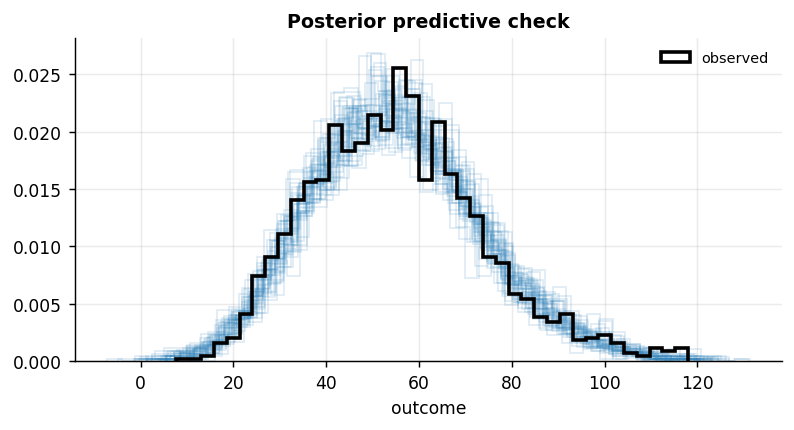

In [9]:
# Genuine posterior predictive: replicate spend from the FITTED BCF — y_rep ~ Normal(mu_draw, sd_draw)
# per posterior draw (mu = prognostic surface + tau*T), NOT a hand-built grand-mean constant.
mu_post, sd_post = bcf_full["mu"], bcf_full["sd"]          # (draws, N) and (draws,)
sel = rng.choice(mu_post.shape[0], size=40, replace=False)
y_rep = mu_post[sel] + rng.normal(0, 1, size=(40, N)) * sd_post[sel, None]
fig, ax = plt.subplots(figsize=(6.2, 3.4))
plots.ppc_plot(ax, y, y_rep)
fig.tight_layout()
_lo, _hi = np.percentile(y_rep, [5, 95])
_cov = float(np.mean((y >= _lo) & (y <= _hi)))
_ppc = "no gross misfit" if 0.82 <= _cov <= 0.98 else "a possible misfit — inspect the tails"
print(f"Posterior-predictive check: {_cov:.0%} of observed spend falls within the replicates' 5–95% "
      f"range (≈90% if calibrated) — {_ppc} (posterior σ ≈ €{sd_post.mean():.0f}).")

## 5 · Validate — did we recover the truth, is the uncertainty honest, and does it rank well?

This is the payoff of simulating a known truth. Three questions, each with its own diagnostic:

**(a) Recovery & calibration — are the numbers right, and honestly uncertain?**
- **PEHE** (*Precision in Estimation of Heterogeneous Effects*) — the root-mean-square error between the
  estimated $\hat\tau(x)$ and the true $\tau(x)$, in €. Lower is better; it's the CATE analogue of RMSE.
- **Coverage** — a *90% credible interval* should contain the true effect about 90% of the time. We also
  break coverage out *by decile of the true effect* to catch a model that's well-calibrated on average but
  overconfident for the biggest effects.
- **Reliability** — bucket customers by predicted effect and plot mean-predicted vs mean-true; on the 45°
  line means the *magnitudes* are calibrated, not just the ranking.
- **Sharpness** — the average width of the intervals. Sharp *and* calibrated is the goal; sharp *and*
  miscalibrated is just overconfidence, which is why we never report sharpness alone.

**(b) Ranking quality — for targeting, the *order* matters more than exact magnitudes.**
- **Qini / uplift curve** — walk down customers from highest to lowest predicted effect, contacting as you
  go, and plot the cumulative *true* effect captured. A good model's curve bows up toward the **oracle**
  (a hypothetical model that knows every true τ) and well above the **random** diagonal.
- **AUUC** (*Area Under the Uplift Curve*) — that curve's area, normalised so **1.0 = oracle-perfect
  ranking** and **0 = no better than random**. The single number for "how well do we rank?"
- **Uplift-by-decile** — average *true* effect within each tenth of predicted effect; a good model shows a
  clean descending staircase (top decile = biggest real effect).

**(c) Stability — is the result a fluke of one random draw?** We refit on several fresh simulations and
check the recovery is consistent.


PEHE €4.76  ·  corr(est,true) 0.90  ·  90% coverage 86%  ·  interval sharpness €12.9


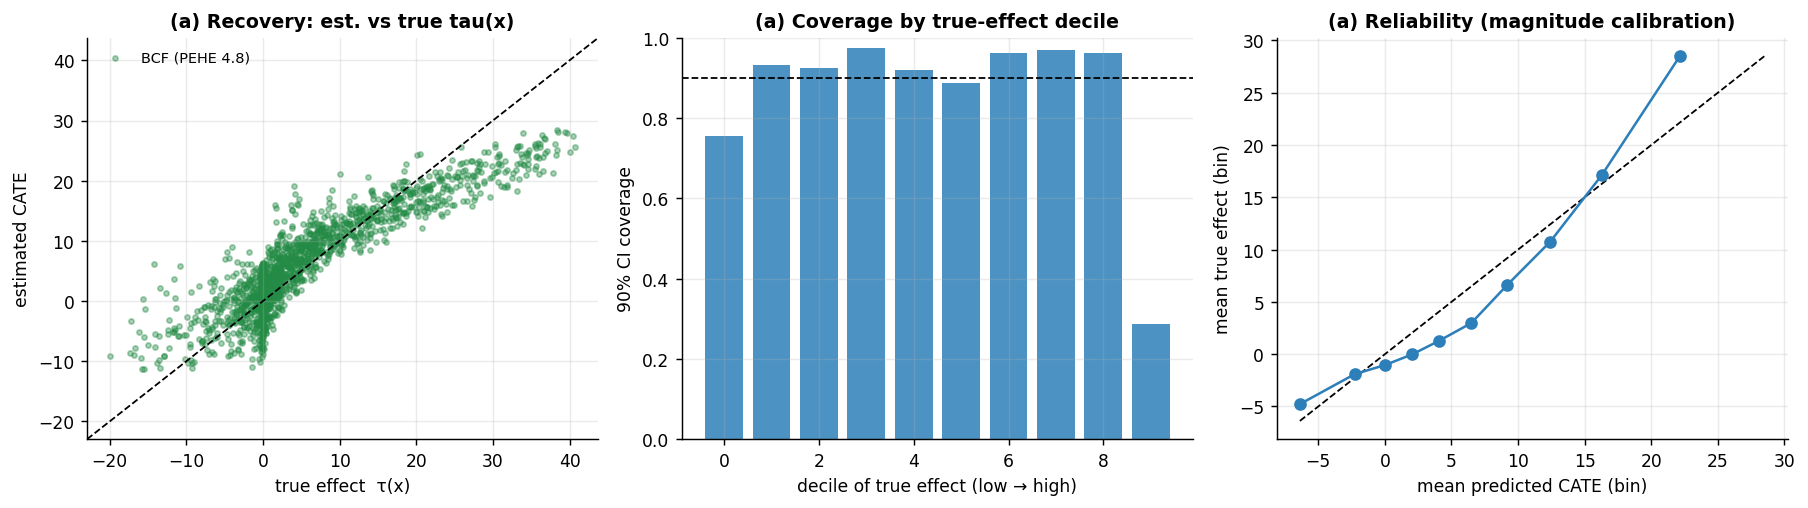

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
plots.recovery_scatter(ax[0], tau, {"BCF": cate_point}, title="(a) Recovery: est. vs true tau(x)")
cov, by_dec = metrics.interval_coverage(cate_bcf, tau, level=0.90, by_decile=True)
plots.calibration_by_decile(ax[1], by_dec, level=0.90); ax[1].set_title("(a) Coverage by true-effect decile")
pred_b, true_b = metrics.reliability_curve(cate_point, tau)
plots.reliability_plot(ax[2], pred_b, true_b); ax[2].set_title("(a) Reliability (magnitude calibration)")
fig.tight_layout()
print(f"PEHE €{metrics.pehe(cate_bcf, tau):.2f}  ·  corr(est,true) {metrics.corr_with_truth(cate_point, tau):.2f}  "
      f"·  90% coverage {cov:.0%}  ·  interval sharpness €{metrics.sharpness(cate_bcf):.1f}")

**Read-out.** The recovery scatter and the line just printed tell one story: a high est-vs-true
correlation and a small **PEHE** (a few € against true effects that span roughly −€10 to +€40) say the
*ranking* is strong and the magnitudes are close, while the printed **90% coverage** lands a touch under
its 90% target — a mild over-confidence that the middle panel pins to the largest-effect deciles and that
Step 5's coverage caveat (below) returns to. Sharpness is read only alongside that coverage, never on its
own, so a narrow-but-miscalibrated interval can't pass itself off as precision.

AUUC = 0.93 of oracle (1.0 = perfect ranking, 0 = random).
(oracle-graded: uses the known τ; on real RCT data use metrics.qini_observed, which reweights
 observed outcomes by arm and needs no counterfactual — see §6b.)
Top decile true effect €28.5  vs  bottom decile €-4.8 — the model concentrates the real uplift where we'd actually spend.


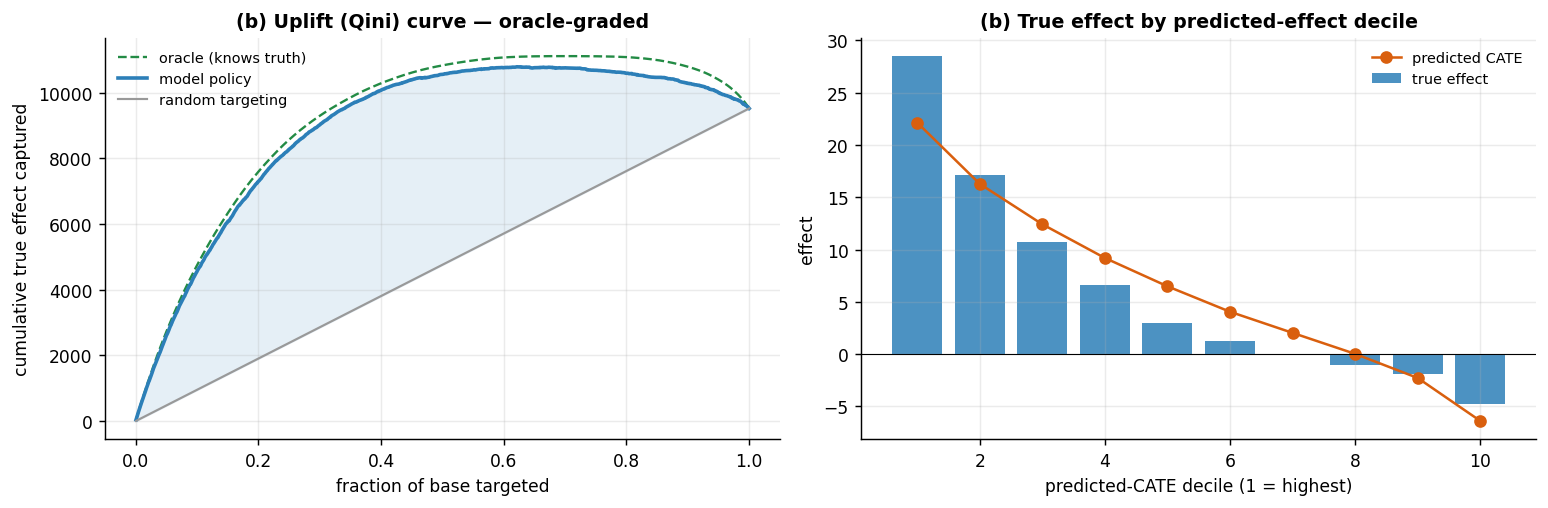

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
frac, cum_m, cum_r, cum_o = metrics.qini_curve(cate_point, tau)   # fraction targeted, model, random, oracle curves
auuc_val = metrics.auuc(cate_point, tau)
plots.qini_plot(ax[0], frac, cum_m, cum_r, cum_o, auuc_val=auuc_val); ax[0].set_title("(b) Uplift (Qini) curve — oracle-graded")
dec = metrics.uplift_by_decile(cate_point, tau)
plots.uplift_decile_plot(ax[1], dec); ax[1].set_title("(b) True effect by predicted-effect decile")
fig.tight_layout()
print(f"AUUC = {auuc_val:.2f} of oracle (1.0 = perfect ranking, 0 = random).")
print("(oracle-graded: uses the known τ; on real RCT data use metrics.qini_observed, which reweights\n"
      " observed outcomes by arm and needs no counterfactual — see §6b.)")
print(f"Top decile true effect €{dec.true_effect.iloc[0]:.1f}  vs  bottom decile €{dec.true_effect.iloc[-1]:.1f} "
      f"— the model concentrates the real uplift where we'd actually spend.")

*Heads-up on the output below:* the sweep deliberately refits BCF with **short 80-draw chains** — enough for stable posterior *means* (all we read here), not for interval-grade diagnostics. The repeated `Only 80 samples per chain` notices are that choice talking; we leave them visible rather than model the habit of silencing sampler diagnostics on a cell whose output we quote.

In [12]:
recs = []
for s in range(4 if FAST else 8):
    d = dgp.uplift_customers(n=N, regime="observational", cost=COST, seed=100 + s)
    Xs, Ts, ys, taus = d[feat].values, d["T"].values, d["y"].values, d["tau"].values
    ph = est.propensity_scores(Xs, Ts, seed=s)
    c = est.bcf(Xs, Ts, ys, ph, seed=200 + s, **{**PROF, "draws": 80, "tune": 80})
    recs.append({"seed": 100 + s, "ATE_hat": c.mean(), "true_ATE": taus.mean(),
                 "PEHE": metrics.pehe(c, taus), "AUUC": metrics.auuc(c.mean(0), taus)})
stab = pd.DataFrame(recs)
print("(c) Stability across fresh simulations:")
print(stab.round(2).to_string(index=False))
_bias = (stab.ATE_hat - stab.true_ATE).mean(); _sd = (stab.ATE_hat - stab.true_ATE).std()
_verdict = "consistent, not a lucky seed" if abs(_bias) < 2 * _sd + 1e-9 else "a systematic bias, not just noise — investigate"
print(f"\nATE recovery bias across seeds: {_bias:+.2f} (sd {_sd:.2f}) — {_verdict}.")

Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>CompoundStep


>>PGBART: [prog]


...

>>PGBART: [prog]


>>PGBART: [tau]


>NUTS: [sd]


Sampling 4 chains for 80 tune and 80 draw iterations (320 + 320 draws total) took 10 seconds.


(c) Stability across fresh simulations:
 seed  ATE_hat  true_ATE  PEHE  AUUC
  100     5.65      5.61  5.12  0.93
  101     5.76      6.12  4.77  0.94
  102     5.57      5.64  5.33  0.94
  103     6.17      5.63  4.77  0.94
  104     5.85      5.75  5.20  0.93
  105     5.90      5.78  5.31  0.92
  106     5.16      5.34  4.83  0.95
  107     6.32      5.84  5.11  0.93

ATE recovery bias across seeds: +0.08 (sd 0.31) — consistent, not a lucky seed.


### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

Step 0 built a complete classical uplift model with no priors in it: a per-customer $\hat\tau(x)$ from a
GBM T-learner, plus a bootstrap band. §4 built a BCF posterior. **Same estimand, same three assumptions,
same data.** Below they meet on this notebook's own four axes — magnitude (PEHE), ranking (AUUC/Qini),
interval honesty (coverage, overall *and* by decile of the true effect), and sharpness — and then on the
only grade that pays anyone: the **euro decision** of §6, run early here so the comparison is complete.

The decision rules put a fair, *unhelpful-to-us* version of the classical arm on the field. Rather than
score it only on "point estimate > cost", we also let it use the bootstrap: a lower-confidence-bound rule
(*is the whole 90% band above the cost?*) and — the closest thing the frequentist toolbox has to §6's
rule — the **bootstrap exceedance share**, the fraction of resamples in which $\hat\tau^{*}(x) > €8$,
thresholded at the same 0.8. If the posterior's advantage is real, it has to show up against *those*.

In [13]:
# --- 5x · The classical arm (Step 0) vs the Bayesian posterior (section 4), on the SAME estimand ---
# NOTHING IS REFIT. cl_t / tboot come from Step 0; cate_bcf / cate_point from section 4.
p_bcf   = (cate_bcf > COST).mean(0)          # POSTERIOR probability that THIS customer clears the cost
share_b = (tboot > COST).mean(0)             # bootstrap EXCEEDANCE SHARE -- looks the same, is not (below)
bcf_cov, bcf_by_dec = metrics.interval_coverage(cate_bcf, tau, level=0.90, by_decile=True)

print("RECOVERY, RANKING, CALIBRATION -- the four axes of section 5, both arms:")
print(f"{'arm':<28}{'PEHE':>7}{'corr':>7}{'AUUC':>7}{'cov90':>8}{'top-dec':>9}{'bot-dec':>9}{'width':>8}")
for nm, pt, c_, d_ in (("classical T-learner (Step 0)", cl_t, cl_cov, cl_by_dec),
                       ("BCF posterior (section 4)",    cate_point, bcf_cov, bcf_by_dec)):
    smp = tboot if nm.startswith("classical") else cate_bcf
    print(f"{nm:<28}{metrics.pehe(pt[None, :], tau):>7.2f}{metrics.corr_with_truth(pt, tau):>7.2f}"
          f"{metrics.auuc(pt, tau):>7.2f}{c_:>8.0%}{d_.iloc[-1]:>9.0%}{d_.iloc[0]:>9.0%}"
          f"{metrics.sharpness(smp):>8.1f}")
_w = lambda a, b, lo=False: "BCF" if ((b < a) if lo else (b > a)) else "classical"
print(f"\n  winner --  PEHE: "
      f"{_w(metrics.pehe(cl_t[None,:], tau), metrics.pehe(cate_point[None,:], tau), lo=True)}"
      f"   ·   AUUC: {_w(metrics.auuc(cl_t, tau), metrics.auuc(cate_point, tau))}")
print(f"             overall coverage (closest to 90%): "
      f"{'BCF' if abs(bcf_cov-0.9) < abs(cl_cov-0.9) else 'classical'}"
      f"   ·   TOP-decile coverage: {_w(cl_by_dec.iloc[-1], bcf_by_dec.iloc[-1])}")

# --- THE DECISION, which is the only grade that pays anyone --------------------------------------
realised = lambda m: float(((tau - COST) * m).sum())      # true euros: sum of (true effect - cost) over targeted
orc = realised(tau > COST)
RULES = [("email everyone",                          np.ones(N, bool)),
         ("classical · point CATE > cost",           cl_t > COST),
         ("classical · bootstrap 90% band all > cost", np.percentile(tboot, 5, axis=0) > COST),
         ("classical · bootstrap share > 0.8",       share_b > 0.8),
         ("BCF · posterior mean > cost",             cate_point > COST),
         ("BCF · P(tau > cost) > 0.8   [section 6's rule]", p_bcf > 0.8),
         ("oracle (knows every true tau)",           tau > COST)]
print(f"\nTHE EURO DECISION at cost EUR {COST:.0f} -- realised profit on the KNOWN truth:")
print(f"  {'targeting rule':<48}{'contacted':>10}{'profit':>12}{'% of oracle':>13}")
for lab, m in RULES:
    print(f"  {lab:<48}{int(m.sum()):>10}{realised(m):>11,.0f} EUR{realised(m)/orc:>12.0%}")

# --- Is the exceedance share a probability? Grade both claims against what actually happened -----
_bayes = realised(p_bcf > 0.8)
_best_cl = max(realised(cl_t > COST), realised(np.percentile(tboot, 5, axis=0) > COST),
               realised(share_b > 0.8))
print(f"\n  the posterior rule earns EUR {_bayes - _best_cl:+,.0f} against the BEST classical rule on\n"
      f"  the board -- {abs(_bayes - _best_cl) / orc:.1%} of the EUR {orc:,.0f} oracle prize. Whatever the Bayesian\n"
      f"  layer is buying in this notebook, on THIS decision, at THIS n, it is not a\n"
      f"  pile of euros. Say it out loud.")

print("\nAND THE COLUMN THAT DOES NOT EXIST. Both arms hand section 6 a number in [0,1] per")
print("customer. Bucket customers by it and ask: of those told '~p', what SHARE truly had")
print("tau_i > cost?")
print(f"  {'bucket':<14}{'n':>6}{'BCF: claim':>12}{'actual':>9}{'   |':>5}{'n':>6}{'boot: claim':>13}{'actual':>9}")
edges = [0, .2, .4, .6, .8, 1.0]
for i in range(len(edges) - 1):
    lo_, hi_ = edges[i], edges[i + 1]
    row = f"  {f'({lo_:.1f}, {hi_:.1f}]':<14}"
    for p in (p_bcf, share_b):
        m = (p > lo_) & (p <= hi_) if i else (p >= lo_) & (p <= hi_)
        row += (f"{int(m.sum()):>6}{p[m].mean():>12.2f}{(tau[m] > COST).mean():>9.2f}"
                if m.sum() else f"{0:>6}{'-':>12}{'-':>9}")
        row += f"{'   |':>5}" if p is p_bcf else ""
    print(row)
print("\n  Read each 'actual' column against its 'claim'. Neither number is a perfectly")
print("  calibrated probability -- both are optimistic in the middle buckets. But only ONE")
print("  of them is even TRYING to be one: P(tau_i > cost) is a statement about the")
print("  CUSTOMER, and it is what section 6's rule, the confidence sweep, the straddler set")
print("  and the euro value-of-information in Depth C are every one of them written in.")
print("  The bootstrap share is a statement about the ESTIMATOR -- how often a refitted")
print("  T-learner would land above EUR 8 if we redrew the customer list. It is centred on")
print("  tau-hat, not on tau_i, and nothing licenses reading it as a belief about a person.")

RECOVERY, RANKING, CALIBRATION -- the four axes of section 5, both arms:
arm                            PEHE   corr   AUUC   cov90  top-dec  bot-dec   width
classical T-learner (Step 0)   5.21   0.89   0.89     86%      78%      78%    13.0
BCF posterior (section 4)      4.76   0.90   0.93     86%      29%      76%    12.9

  winner --  PEHE: BCF   ·   AUUC: BCF
             overall coverage (closest to 90%): classical   ·   TOP-decile coverage: classical

THE EURO DECISION at cost EUR 8 -- realised profit on the KNOWN truth:
  targeting rule                                   contacted      profit  % of oracle
  email everyone                                        1600     -3,277 EUR        -60%
  classical · point CATE > cost                          589      4,815 EUR         88%
  classical · bootstrap 90% band all > cost              346      4,891 EUR         90%
  classical · bootstrap share > 0.8                      449      5,137 EUR         94%
  BCF · posterior mean > cost 

**The honest verdict — what the posterior bought, and what it did not.**

**1 · On the ATE, they agree — say it plainly.** Step 0's adjusted classical estimators and §4's BCF
posterior land on the same ~€6 average effect, all of them within a euro of the planted truth. The
Bayesian layer did not find a better number. It could not: with 1,600 customers, fully observed
confounders and weak priors, a correctly-adjusted regression is already consistent, and there was
nothing left on the table. **The causal work was done by the identification of §3, not by the
machinery of §4.** If you came here expecting "going Bayesian" to fix a biased estimate, Step 0 is the
correction: what fixed the bias was *adjusting for the five features*, and OLS does that for free.

**2 · On the CATE, BCF genuinely wins — on magnitudes and on ranking.** Read the first table (and the
computed `winner` line under it — never this paragraph, if the two disagree). At the **FULL** profile,
which is what the committed outputs show, BCF beats the classical GBM T-learner on **PEHE** and on
**AUUC**, by a margin that survives re-running with fresh BART seeds. *Under the FAST profile the PEHE
edge can vanish or invert* — FAST deliberately runs 140-draw chains on 30 trees, which is not enough
posterior for the shrinkage to pay for itself; the AUUC win is the sturdier of the two. This is worth
being precise about, because the easy explanation is the wrong one: the
win is *not* the propensity trick (Depth A's bake-off shows BCF ≈ the **BART** T-learner on this same
data, so feeding $\hat e(x)$ in is buying little when the confounders are fully observed — §7's caveat
says so). The win is the **prior and the averaging**: BCF's CATE is an average over a posterior of tree
ensembles, with a shrink-toward-homogeneity prior on the treatment surface, so it reports heterogeneity
only where the data insist. The boosted T-learner is a single point fit that must commit. At $n=1{,}600$
with a noisy outcome ($\sigma \approx €8$ against effects spanning −€10 to +€40), regularised averaging
is worth several tenths of a euro of PEHE and several points of AUUC. **That is a real, measured
Bayesian win, and it is the ordinary kind: shrinkage beats a point fit when the signal is thin.**

**3 · On the intervals, BCF does *not* win — and in the one place that matters, it loses badly.** This
is the finding we did not expect and will not bury. Overall 90% coverage is a wash: both arms land in
the mid-80s, both mildly overconfident. But split by decile of the *true* effect and the two arms come
apart at the top: the bootstrap band around the T-learner still covers a majority of the largest-effect
customers, while **BCF's credible interval covers only a small fraction of them** (read the `top-dec`
column; across BART seeds we see it in the 20–40% range against the bootstrap's ~80%). The cause is not
a bug, it is the *same* prior that won us round 2: shrinkage toward homogeneity pulls the biggest $\tau_i$
down, and the posterior then reports a *narrow* interval around the shrunken value. The classical arm,
having no shrinkage to apply, is less accurate on average and more honest at the extreme. **The
Bayesian model bought its PEHE and AUUC with exactly the coin it then failed to cover the tail with.**
This is the notebook's existing coverage caveat (Depth A, and the closing paragraph), now with a
*comparator*: it is not merely that BCF's tail intervals are imperfect — a competently bootstrapped
classical T-learner does better there.

**4 · On the decision, the posterior bought almost nothing — and the reason to prefer it is not the
euros.** Read the profit table. Emailing everyone *destroys* value (the sleeping dogs see to that), and
every model-driven rule recovers the great majority of the oracle's profit. But now look at the top two
rows of it: §6's honest posterior rule, $P(\tau_i>\text{cost})>0.8$, and the classical
**bootstrap-exceedance-share** rule at the identical 0.8 threshold finish *level* — the printed gap
between them is a rounding error against a five-figure prize — and both beat targeting on either arm's
bare *point* estimate (which over-contacts, because a point estimate cannot tell a confident €9 from a
coin-flip €9). **On this decision, at this $n$, the Bayesian layer bought essentially no extra euros.
Say it out loud.** So what is the durable argument?

It is the last table, and it is not a philosopher's quibble. Both arms emit a number in $[0,1]$ per
customer, and the two numbers **answer different questions**. $P(\tau_i > \text{cost})$ is a probability
about *this customer's effect*, computed by integrating a posterior — the object §6's rule, §6's
confidence sweep, Depth C's **straddler** set and Depth C's euro **value of information** are every one
of them defined as expectations over. The bootstrap share is the frequency with which a *refitted
estimator* would exceed €8 across resampled customer lists: it is centred on $\hat\tau(x)$, it inherits
the learner's shrinkage in every single replicate (so it cannot warn you that it is biased — the top
decile is the proof), and nothing licenses reading it as a degree of belief about the customer. That it
*performs* nearly as well here as a decision heuristic is the honest, uncomfortable finding, and we
report it. What it cannot do is be *interpreted*, *dialled* against a stated risk appetite, or fed to a
VOI integral without silently changing the meaning of every euro that comes out.

**What Bayes did NOT buy here.** Not the ATE — Step 0 had it, three ways, with honest HC1 and bootstrap
intervals. Not immunity from the untestable assumption: Depth B's confounder drags the posterior exactly
as far as it drags OLS. Not calibrated intervals on the biggest effects — it is *worse* there than the
bootstrap, which is why the closing recommendation is a **test on the straddlers**, not blind faith in
$\hat\tau$. Not, on this data, a large pile of extra euros. What it bought is a **better estimate of
$\tau(x)$** (PEHE, AUUC — earned, measured, seed-stable) and the **decision quantity itself**: a
per-customer probability that a CMO can threshold, sweep and price. On a smaller list, or a noisier
outcome, the shrinkage margin grows. On this one, be honest: the classical arm got remarkably close.

## 6 · Decide, in euros

An effect estimate is useless until it becomes an action and a number a manager signs off on. Three moves:

**Compare targeting policies on realised profit.** We evaluate five rules on the *known truth* (only
possible in simulation) so we can see, in €, how much targeting beats the alternatives and how close it
gets to the unbeatable oracle:
- *treat-all* (email everyone), *random-50%*,
- *model (mean > cost)* — email where the posterior-mean effect beats the €8 cost,
- *model (P > conf)* — the **honest rule**: email only where we're *confident* the effect beats cost
  (see below), and
- *oracle* — email exactly the customers whose *true* effect beats cost (the best any model could do).

**The honest targeting rule.** We do **not** target on "mean effect > cost." A customer whose point
estimate says "target" but whose interval straddles the cost line is a coin-flip, not a yes. So we target
where $P(\tau(x) > \text{cost})$ is **high** (here > 0.8) — probability, from the posterior, that the
effect really clears the cost.

**The profit curve.** Rank customers by estimated effect, contact down the list, and plot cumulative
`(true effect − cost)`. It rises while we're adding profitable customers and falls once we hit
unprofitable ones; its **peak is the optimal stopping point** — "email the top X%, make €Y."


           policy  profit frac_contacted  profit_vs_all
        treat-all   -3277           100%              0
       random-50%   -1633            49%           1644
model (mean>cost)    4965            40%           8242
   model (P>conf)    5204            28%           8481
           oracle    5459            30%           8735

Email everyone: €-3,277  ·  honest model rule: €5,204 (95% of the oracle's profit), targeting 452 of 1600 customers.


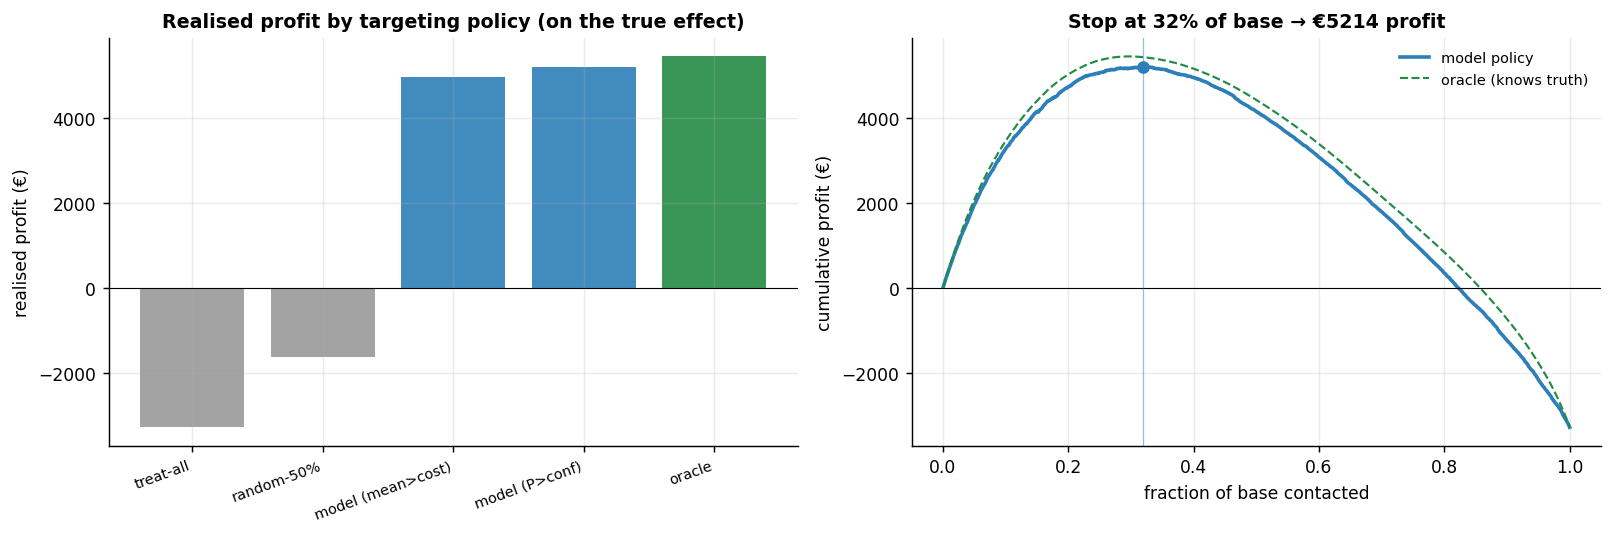

In [14]:
comp = policy.policy_comparison(cate_bcf, tau, COST, confidence=0.8, seed=SEED)
mask, p_worth = policy.target_set(cate_bcf, COST, confidence=0.8)   # who to target under the honest rule
frac_p, cum_p, stop = policy.profit_curve(cate_point, tau, COST)
_, oracle_p, _ = policy.profit_curve(tau, tau, COST)               # oracle profit curve (knows the truth)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
plots.policy_bar(ax[0], comp); ax[0].set_title("Realised profit by targeting policy (on the true effect)")
plots.profit_plot(ax[1], frac_p, cum_p, stop, oracle_profit=oracle_p)
fig.tight_layout()

# Format for display: euros as whole numbers, fraction contacted as a %, so the
# table doesn't round 0.26 -> 0 or 0.50 -> 1 (which would contradict the summary).
disp = comp.copy()
disp["profit"] = disp["profit"].round(0).astype(int)
disp["profit_vs_all"] = disp["profit_vs_all"].round(0).astype(int)
disp["frac_contacted"] = (disp["frac_contacted"] * 100).round(0).astype(int).astype(str) + "%"
print(disp.to_string(index=False))
capture = comp.loc[comp.policy=="model (P>conf)","profit"].values[0] / comp.loc[comp.policy=="oracle","profit"].values[0]
print(f"\nEmail everyone: €{comp.loc[comp.policy=='treat-all','profit'].values[0]:,.0f}  ·  "
      f"honest model rule: €{comp.loc[comp.policy=='model (P>conf)','profit'].values[0]:,.0f} "
      f"({capture:.0%} of the oracle's profit), targeting {int(mask.sum())} of {N} customers.")

## 6b · The same pipeline on **real** data (Hillstrom email experiment)

Everything above used *simulated* data so we could grade recovery. Here we run the identical estimator on
a **real, public dataset you don't have to provide** — it's fetched over the network from a public URL:

> **Hillstrom / MineThatData (2008)** — 64,000 real customers randomly assigned to *Men's email*,
> *Women's email*, or *no email*, with downstream visits, conversion and spend. We reduce it to a binary
> *Women's-email vs no-email* comparison. Because assignment was **randomized (a true A/B test)**, the
> average effect is trustworthy with no adjustment — but there is **no ground-truth per-customer effect**
> here (real customers only live one future), so we can estimate and decide, but we *cannot* grade CATE
> recovery. That's exactly what production looks like: the validation lives in the simulation above; the
> money is made here.

The cell is **gated** — it fetches only if you set `CMP_REAL=1` (so the offline test suite stays
deterministic). Set it and re-run to see the real-data version.

> **What you'll see — a recorded run.** The committed notebook keeps the gate off so the repo runs
> offline, but for reference a recorded run of this cell (FULL profile, `CMP_REAL=1`) gives: the
> two-arm slice has **n = 42,693** customers (21,387 emailed, 21,306 held out), and the randomized
> comparison yields a causal **ATE ≈ €0.42 per customer (SE ≈ €0.13)** — a genuine, significant
> lift that pays for itself at any realistic cost of sending an email. On the 4,000-customer
> subsample, BCF flagged roughly one customer in ten as a confident target (P(effect>0) > 0.8),
> and ranking by predicted uplift put on the order of **€0.9k of observable incremental spend in
> the top-30% bucket versus essentially nothing (slightly negative — spend is noisy and
> zero-inflated) for a random 30%** — a real observable-Qini win, computed with no counterfactual.
> Two different kinds of number in that list: the sample sizes and the ATE are exact properties of
> the fixed public dataset and reproduce to the cent; the BCF-derived read-outs (the ~10%, the
> Qini split) are BART-posterior quantities and pymc-bart is not seed-stable across machines, so
> treat those as orders of magnitude and run `CMP_REAL=1` to get your own.


In [15]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    real = data.hillstrom_uplift(treat_segment="Womens E-Mail", outcome="spend")
    Xr, Tr, yr = real["X"], real["T"], real["y"]
    print(real["note"]); print(f"n = {real['n']:,}  ·  features = {real['feature_names']}")
    naive_ate = yr[Tr==1].mean() - yr[Tr==0].mean()   # unbiased because randomized
    phr = est.propensity_scores(Xr, Tr, seed=1)
    sub_idx = np.random.default_rng(1).choice(len(Tr), size=min(4000, len(Tr)), replace=False)  # random subsample (rows are iid), not a head slice
    cate_r = est.bcf(Xr[sub_idx], Tr[sub_idx], yr[sub_idx], phr[sub_idx], seed=1, **{**PROF, "draws": 80, "tune": 80})
    p_worth_r = (cate_r > 0).mean(0)                   # cost ~ 0 here (email is cheap); target where effect likely > 0
    print(f"\nRandomized (causal) ATE of the email on spend: €{naive_ate:.3f}/customer")
    print(f"BCF would target {(p_worth_r>0.8).mean():.0%} of customers where P(effect>0) > 0.8 (email cost ≈ 0)")
    fo, cum_o = metrics.qini_observed(cate_r.mean(0), Tr[sub_idx], yr[sub_idx])   # observable uplift — no ground-truth tau
    ktop = max(1, int(0.3 * len(fo)))
    print(f"Observable Qini: targeting the top 30% by predicted uplift captures €{cum_o[ktop]:.0f} incremental "
          f"spend vs €{cum_o[-1]*0.3:.0f} from a random 30% — computed with no counterfactual.")
    print("No per-customer recovery check is possible — real customers have no observed counterfactual.")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run this cell to fetch the Hillstrom experiment.")
    print("On real data there is no ground-truth tau, so Steps 5's recovery checks do not apply.")

Real-data section skipped. Set CMP_REAL=1 and re-run this cell to fetch the Hillstrom experiment.
On real data there is no ground-truth tau, so Steps 5's recovery checks do not apply.


## 7 · Caveats — the honest failure modes

- **Unconfoundedness is untestable.** If a *hidden* driver moved both who got emailed and how much they
  spend (say a salesperson's hunch we never recorded), the estimate drifts. Depth B quantifies exactly how
  strong such a confounder would have to be to flip the decision — as an **E-value**.
- **Overlap matters.** Where some kind of customer was *always* emailed, we're extrapolating, not
  comparing. We checked the tails in Step 4 and can trim them.
- **Estimator choice is not cosmetic.** The S-learner (Depth A) regularises the treatment signal away and
  under-detects heterogeneity — it fails on both PEHE *and* ranking (AUUC).
- **BCF ≈ T-learner when confounders are fully observed.** The propensity trick earns its keep specifically
  under *targeted selection*; don't oversell it as free lunch. (5x does find BCF beating a *classical* GBM
  T-learner on PEHE and AUUC — but that win comes from BART's prior and posterior averaging, not from the
  propensity input: Depth A's bake-off shows BCF landing on top of the **BART** T-learner on this same data.)
- **Our per-customer intervals are worst exactly where the money is.** 5x grades BCF's credible intervals
  against a bootstrapped classical T-learner and BCF **loses on the top decile of true effect** — the same
  shrink-toward-homogeneity prior that wins us PEHE and AUUC pulls the biggest effects down and then reports a
  narrow interval around the shrunken value. Read every `P(τ>cost)` as a decision *input*, not gospel, and
  note that this is precisely why the recommendation ends on "test the straddlers".
- **Sleeping dogs are real.** Negative-effect customers mean "email everyone" can be *value-destroying*, not
  merely wasteful — which is exactly what the policy comparison in Step 6 showed.


---
# Depth A · Estimator bake-off & failure modes

*Why a whole section on picking the estimator?* Because the choice is not cosmetic — a popular default
(the S-learner) systematically **flattens** heterogeneity and would quietly wreck the targeting. We line up
three estimators against the known truth, in two worlds, on the metrics that actually matter for targeting.

**The three estimators (meta-learners — recipes that turn any regression into a CATE estimator):**
- **S-learner** ("S" = single) — fit *one* model of spend on features *and* treatment together, then read
  the effect as (prediction with $T{=}1$) − (prediction with $T{=}0$). Simple, but the model can shrink the
  treatment's influence toward zero, **flattening** real differences. This is the labelled failure mode.
- **T-learner** ("T" = two) — fit *separate* models on the emailed and not-emailed customers, then subtract.
  A solid default when treatment is randomized.
- **BCF** — the propensity-aware, shrink-to-homogeneity model from Step 4; best under confounding.

**The two worlds:**
- **Randomized** — treatment was a coin flip, so *unconfoundedness holds by design* and even simple methods
  are unbiased on the average.
- **Observational** — the confounded world we've been in; here the naive "emailed − not-emailed" average is
  badly biased, and the estimator has to actively undo the confounding.

**The metrics:** PEHE (magnitude error, €), corr (ranking correlation), **AUUC** (ranking quality vs oracle),
ATE_bias (average-effect error, €), and cov90 (are the 90% intervals honest?).


In [16]:
BPROF = dict(draws=90, tune=90, chains=2, m=25) if FAST else dict(draws=500, tune=500, chains=4, m=100)
dfr = dgp.uplift_customers(n=N, regime="randomized", cost=COST, seed=SEED)   # a randomized twin of the same customers
Xr, Tr, yr, taur = dfr[feat].values, dfr["T"].values, dfr["y"].values, dfr["tau"].values
phat_r = np.full(N, 0.5)                                                     # propensity is 0.5 by design

rows, store = [], {}
def run(regime, name, cate, tau_):
    r = metrics.bakeoff_row(cate, tau_, name, regime)
    r["AUUC"] = metrics.auuc(cate.mean(0), tau_)
    rows.append(r); store[(regime, name)] = cate

run("randomized", "S-learner", est.s_learner(Xr, Tr, yr, seed=11, **BPROF), taur)
run("randomized", "T-learner", est.t_learner(Xr, Tr, yr, seed=21, **BPROF), taur)
run("randomized", "BCF",       est.bcf(Xr, Tr, yr, phat_r, seed=31, **BPROF), taur)
run("observational", "S-learner", est.s_learner(X, T, y, seed=41, **BPROF), tau)
run("observational", "T-learner", est.t_learner(X, T, y, seed=51, **BPROF), tau)
run("observational", "BCF",       est.bcf(X, T, y, phat, seed=61, **BPROF), tau)   # refit at BPROF so the bake-off compares equal compute (not the richer cell-11 fit)

bake = pd.DataFrame(rows)[["regime","estimator","PEHE","corr","AUUC","ATE_bias","cov90"]]
naive = dm_obs.estimate   # Step 0's cl.diff_in_means — the naive confounded difference-of-means, reused
print(f"Naive 'emailed - not emailed' (observational, Step 0): €{naive:.1f} vs true €{tau.mean():.1f} "
      f"-> bias {naive - tau.mean():+.1f}  (confounding nearly doubles the apparent effect)")
bake.round(2)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>PGBART: [mu]


>NUTS: [sd]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 29 seconds.


...

>>PGBART: [tau]


>NUTS: [sd]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 40 seconds.


Naive 'emailed - not emailed' (observational, Step 0): €11.4 vs true €6.0 -> bias +5.4  (confounding nearly doubles the apparent effect)


,regime,estimator,PEHE,corr,AUUC,ATE_bias,cov90
0,randomized,S-learner,9.16,0.75,0.84,-0.69,0.38
1,randomized,T-learner,4.10,0.93,0.96,-0.44,0.89
2,randomized,BCF,4.79,0.91,0.95,-0.51,0.85
3,observational,S-learner,9.11,0.78,0.86,0.46,0.33
4,observational,T-learner,4.20,0.92,0.94,0.61,0.93
5,observational,BCF,4.85,0.90,0.93,0.41,0.84


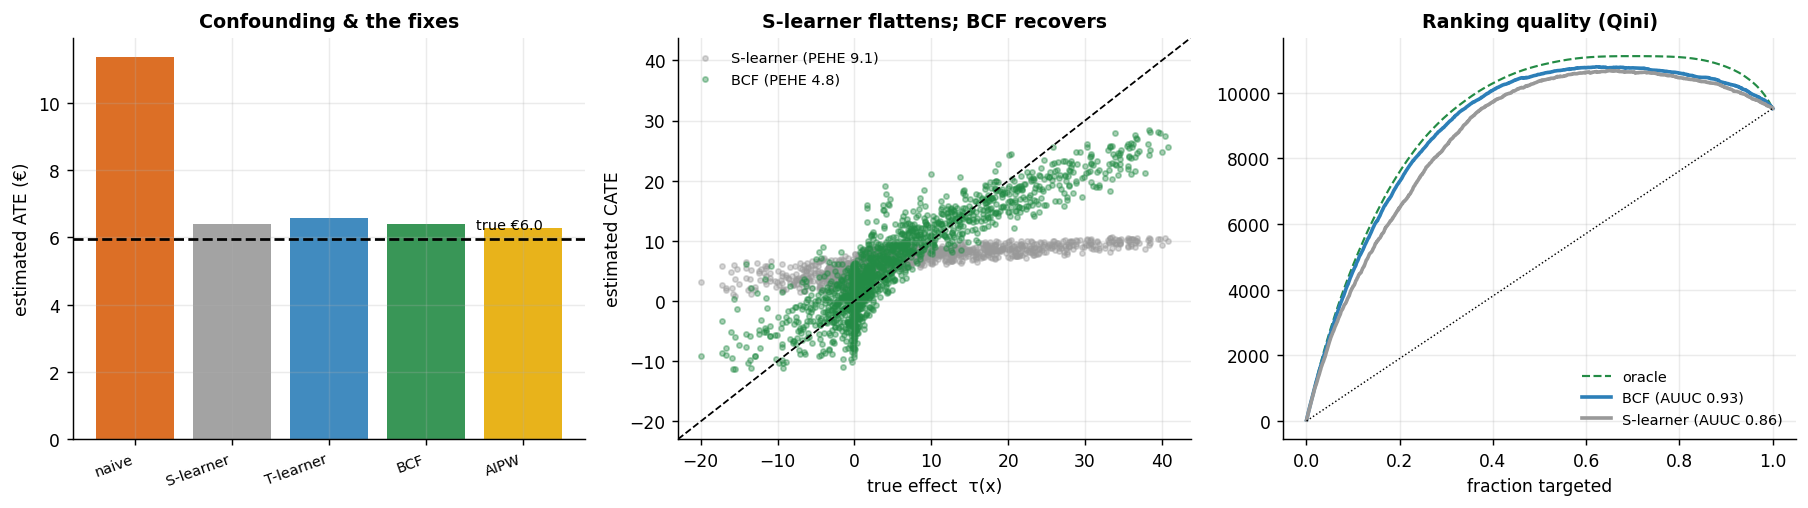

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
names = ["naive", "S-learner", "T-learner", "BCF", "AIPW"]
vals = [naive, store[("observational","S-learner")].mean(), store[("observational","T-learner")].mean(),
        cate_bcf.mean(), aipw["ate"]]
ax[0].bar(names, vals, color=[plots.ORANGE, plots.GREY, plots.BLUE, plots.GREEN, plots.GOLD], alpha=0.9)
ax[0].axhline(tau.mean(), color="k", ls="--"); ax[0].text(4.2, tau.mean()+.3, f"true €{tau.mean():.1f}", ha="right", fontsize=8)
ax[0].set_ylabel("estimated ATE (€)"); ax[0].set_title("Confounding & the fixes"); plt.setp(ax[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)
plots.recovery_scatter(ax[1], tau, {"S-learner": store[("observational","S-learner")].mean(0), "BCF": cate_bcf.mean(0)},
                       title="S-learner flattens; BCF recovers")
f, cmB, cr, co = metrics.qini_curve(cate_bcf.mean(0), tau)
_, cmS, _, _ = metrics.qini_curve(store[("observational","S-learner")].mean(0), tau)
ax[2].plot(f, co, color=plots.GREEN, ls="--", lw=1.2, label="oracle")
ax[2].plot(f, cmB, color=plots.BLUE, lw=2, label=f"BCF (AUUC {metrics.auuc(cate_bcf.mean(0),tau):.2f})")
ax[2].plot(f, cmS, color=plots.GREY, lw=2, label=f"S-learner (AUUC {metrics.auuc(store[('observational','S-learner')].mean(0),tau):.2f})")
ax[2].plot(f, cr, color="k", lw=0.8, ls=":"); ax[2].set_title("Ranking quality (Qini)")
ax[2].set_xlabel("fraction targeted"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()

**Read-out.** Two robust messages and one honest caveat — read them off the table above. (1) **The
S-learner is the clear loser** in both worlds on the metrics that matter for targeting: highest PEHE,
lowest AUUC, and badly under-covering intervals (`cov90` ≈ 0.4). Its single shared surface regularises the
treatment signal toward zero, so it **flattens** heterogeneity even with no confounding to fight — which
wrecks the per-customer ranking. Tellingly, though, its *average* effect is still fine: in the *randomized*
world its ATE bias is ≈ 0 (in fact the smallest in the table). Flattening hurts the per-customer effects and
their ranking, not the mean — which is exactly why a response-style average would miss the problem and only
the heterogeneity metrics expose it. (The T-learner's and BCF's randomized ATE biases, ≈ −0.6 and −0.5, are
themselves small against the ~€6 effect, so all three recover the *level*; the S-learner's fault is
heterogeneity, not the average.) (2)
**The T-learner and BCF land together** — near-identical PEHE, correlation and AUUC — and both agree with
the methodologically different, doubly-robust AIPW estimator (a boosted-tree cross-check) on the ATE, our cross-method credibility check. *Which* of the two
edges the other on any single metric **wobbles run-to-run in FAST mode** (few draws and trees), so we don't
over-read a small PEHE gap; with fully observed confounders and good overlap the two are *expected* to
coincide (Step 7's caveat), and BCF stays the primary model because its propensity input earns its keep
under **targeted selection**, the regime Depth B stress-tests.

> **Coverage — the honest caveat we don't hide.** BCF's 90% intervals tend to **under-cover on the largest
> true effects** — read the `90% coverage` printed above (and the bake-off `cov90` column) for *this* run,
> and see the coverage-by-decile panel in Step 5, where the top true-effect decile is worst. The exact
> figure **wobbles run-to-run** because pymc-bart's sampler is not seed-reproducible; the T-learner's
> intervals are usually a touch better calibrated, and the S-learner under-covers badly (the labelled
> failure-mode). The takeaway is deliberately conservative: heterogeneity is hardest to pin exactly where
> the effect is biggest, so we treat every `P(τ>cost)` downstream as a decision *input*, not gospel, and
> keep the "test the straddlers" recommendation — it hedges precisely where calibration is thinnest.

---
# Depth B · Identification rigour & sensitivity

We already confirmed **overlap** (Step 4). The deeper worry is **unconfoundedness**, which is *untestable*
— so the honest question is not "is it true?" but **"how fragile is our conclusion to a confounder we
didn't measure?"**

We simulate a hidden driver $U$ that moves *both* who gets emailed and how much they spend, sweep its
strength, and refit adjusting for the observed features **only** (blind to $U$, as we'd be in reality). We
report two complementary things a CMO can act on:

- the **tipping point** — the confounder strength at which the (wrongly) adjusted effect crosses the €8 cost
  line and would flip us from "target selectively" to "email everyone pays" (a *decision*-flip number);
- the **E-value** (VanderWeele-Ding) — the minimum strength of association a hidden confounder would need
  with *both* treatment and outcome, on a **risk-ratio scale** — a risk ratio being how many times more
  likely an outcome is under one condition than another, i.e. a multiplicative scale — to explain the
  *positive effect* away entirely (to zero). The E-value is defined only on the risk-ratio scale, so we standardize the euro effect by the
  outcome SD (VanderWeele's continuous-outcome rule) and compute it on the **AIPW estimate** — never on the
  simulation truth, which a real analyst never has. A large E-value means "you'd need an implausibly strong
  hidden confounder to overturn this"; a modest one (as we find here) means the robustness is real but not
  decisive.

The right panel makes the tipping point two-dimensional: it is a **genuinely refit** surface of the
confounded ATE as $U$'s two channels (into treatment, into outcome) vary independently — so the black cost
line traces the real $(a, b)$ frontier, not a drawn-in gradient — omitted-variable bias (**OVB**) in two
dimensions, where the bias scales with *both* channels, $a\times b$.

Tipping point: the observed-feature-adjusted ATE crosses the €8 cost line at hidden-confounder
strength ~ 2.0 — beyond that, confounding alone could fake an 'email everyone pays' signal.
E-value 2.07 (at the near CI limit, 1.94): to explain the positive €6.28 effect
away to zero, a hidden confounder would need ~2.1× association (risk-ratio scale) with BOTH email
and spend. That is moderate, not decisive — ask a domain expert whether anything that strong went unmeasured.


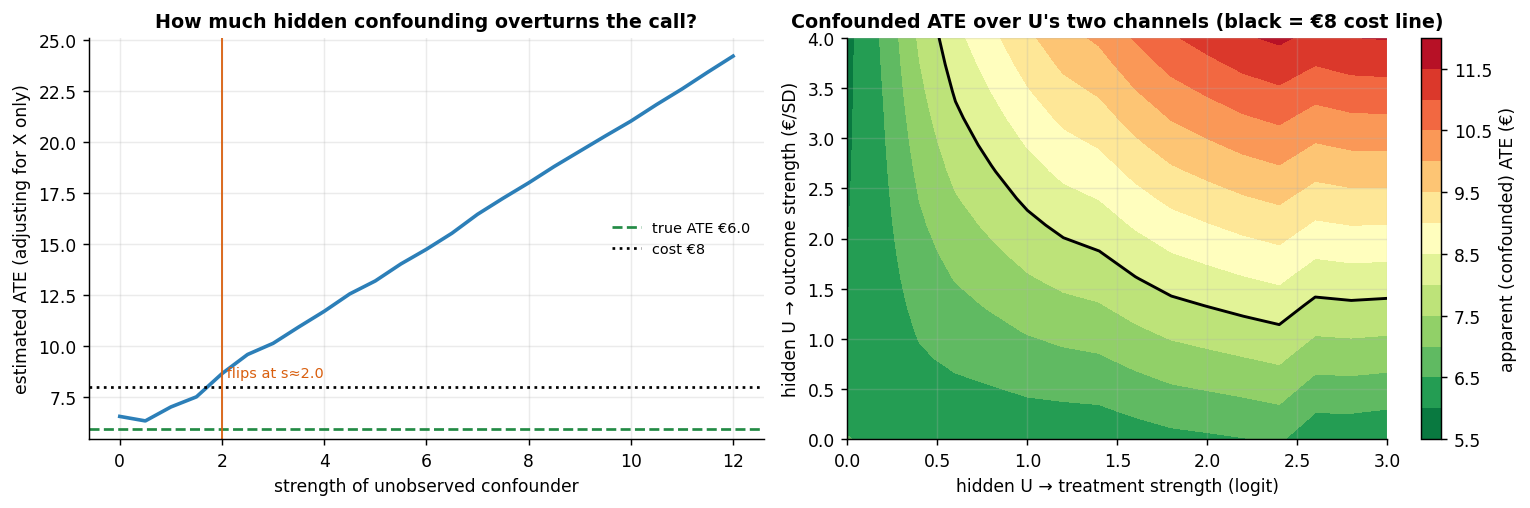

In [18]:
def adjusted_ate(Xd, Td, yd):
    D = np.column_stack([np.ones(len(Td)), Td, Xd])
    return np.linalg.lstsq(D, yd, rcond=None)[0][1]

# (i) Tipping point — sweep the single confounder knob and refit blind to U.
strengths = np.linspace(0, 12, 25)
drift = []
for s in strengths:
    d = dgp.uplift_customers(n=N, regime="observational", confounder_strength=s, cost=COST, seed=SEED)
    drift.append(adjusted_ate(d[feat].values, d["T"].values, d["y"].values))
drift = np.array(drift)
tip = strengths[np.argmax(drift > COST)] if np.any(drift > COST) else np.nan

# (ii) E-value — robustness of the *positive* effect to hidden confounding.
# Computed on the AIPW *estimate* (never the simulation truth), and standardized
# by the outcome SD, because the E-value is defined on the risk-ratio scale and a
# euro effect must be converted first (VanderWeele's continuous-outcome rule,
# RR ~ exp(0.91*d)). cost=0 asks "how strong to explain the effect away to zero".
evalue = metrics.e_value(aipw["ate"], cost=0.0, sd=float(y.std()))
evalue_lo = metrics.e_value(aipw["ci90"][0], cost=0.0, sd=float(y.std()))   # at the near confidence limit

# (iii) A *computed* omitted-variable-bias surface. We give the hidden driver U
# independent strengths into treatment (a, logit scale) and outcome (b, €/SD) and
# refit the observed-feature-adjusted ATE on each. The apparent effect inflates
# only when BOTH channels are on (bias ~ a*b) — real OVB geometry, not a drawn-in
# gradient. The black line is the (a, b) frontier where confounding alone would
# push the estimate past the €8 cost line.
a_grid, b_grid = np.linspace(0, 3, 16), np.linspace(0, 4, 16)
G, Dd = np.meshgrid(a_grid, b_grid)
apparent = np.empty_like(G)
for i in range(G.shape[0]):
    for j in range(G.shape[1]):
        d = dgp.uplift_customers(n=N, regime="observational", cost=COST, seed=SEED,
                                 conf_t=float(G[i, j]), conf_y=float(Dd[i, j]))
        apparent[i, j] = adjusted_ate(d[feat].values, d["T"].values, d["y"].values)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plots.sensitivity_plot(ax[0], strengths, drift, tau.mean(), COST, tipping=tip)
cs = ax[1].contourf(G, Dd, apparent, levels=12, cmap="RdYlGn_r")
ax[1].contour(G, Dd, apparent, levels=[COST], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[1], label="apparent (confounded) ATE (€)")
ax[1].set_xlabel("hidden U → treatment strength (logit)"); ax[1].set_ylabel("hidden U → outcome strength (€/SD)")
ax[1].set_title("Confounded ATE over U's two channels (black = €8 cost line)")
fig.tight_layout()
print(f"Tipping point: the observed-feature-adjusted ATE crosses the €{COST:.0f} cost line at hidden-confounder")
print(f"strength ~ {tip:.1f} — beyond that, confounding alone could fake an 'email everyone pays' signal.")
print(f"E-value {evalue:.2f} (at the near CI limit, {evalue_lo:.2f}): to explain the positive €{aipw['ate']:.2f} effect")
print(f"away to zero, a hidden confounder would need ~{evalue:.1f}× association (risk-ratio scale) with BOTH email")
print("and spend. That is moderate, not decisive — ask a domain expert whether anything that strong went unmeasured.")

---
# Depth C · Euro policy — sweeps, value of information & test design

The decision is a number *under assumptions*. We stress the two a manager will argue about — the per-contact
**cost** and how **confident** we insist on being — and then price the remaining uncertainty and turn it into
a concrete experiment.

**Value of information (VOI).** Uncertainty has a *price*: the euros we lose by acting on the noisy estimate
instead of the (unknown) truth. It concentrates on the **straddlers** — customers whose credible interval
crosses the cost line, so we genuinely can't tell if they're worth contacting. The total VOI on the
straddlers is an **upper bound** on what any experiment on them can be worth: it prices *perfect*
information, whereas a finite A/B test resolves only part of the uncertainty and so is worth strictly
less. Still, it sets the ceiling on sensible test spend — and tells you on whom.


Total value of information €456; €440 of it sits on the 757 'straddler' customers (47% of the base) whose interval crosses the cost line.


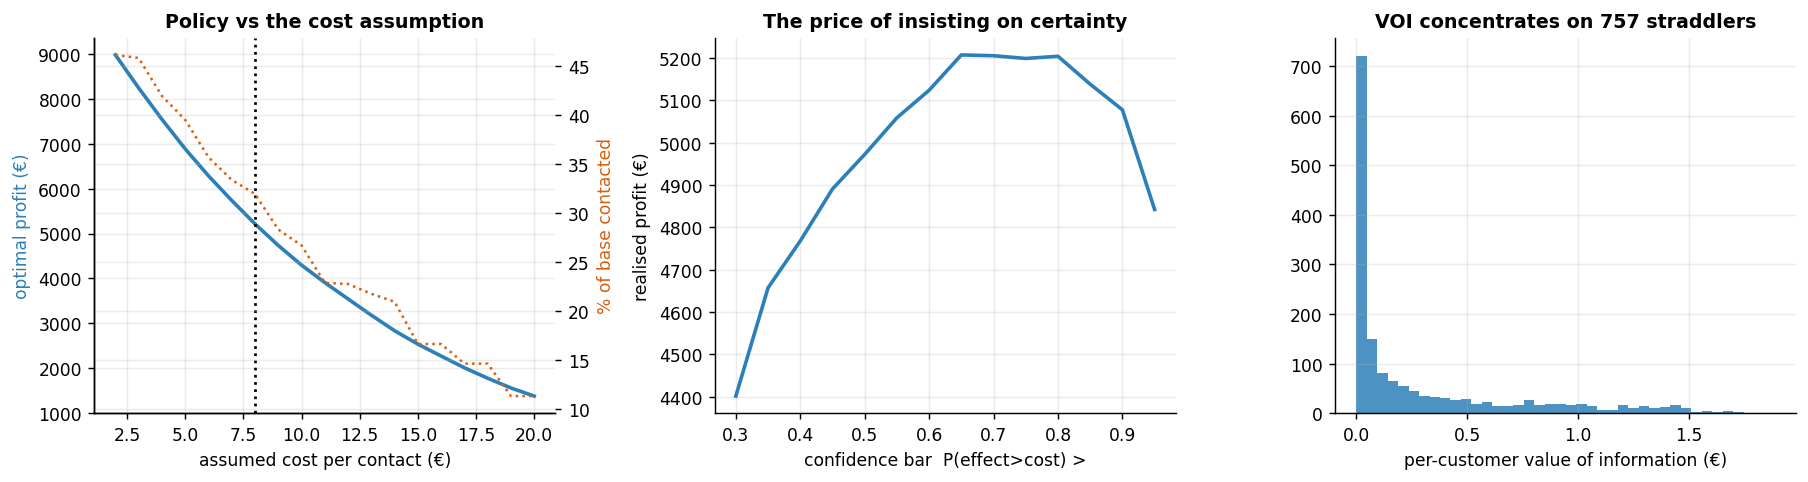

In [19]:
costs = np.linspace(2, 20, 19)
cs = policy.cost_sweep(cate_point, tau, costs)
thr = np.linspace(0.3, 0.95, 14)
conf = policy.confidence_sweep(cate_bcf, tau, COST, thr)
voi = policy.value_of_information(cate_bcf, COST)
size = policy.voi_targeting_size(cate_bcf, COST, confidence=0.8)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(cs["costs"], cs["opt_profit"], color=plots.BLUE, lw=2)
a0 = ax[0].twinx(); a0.plot(cs["costs"], cs["opt_frac"]*100, color=plots.ORANGE, lw=1.4, ls=":")
ax[0].axvline(COST, color="k", ls=":"); ax[0].set_xlabel("assumed cost per contact (€)")
ax[0].set_ylabel("optimal profit (€)", color=plots.BLUE); a0.set_ylabel("% of base contacted", color=plots.ORANGE)
ax[0].set_title("Policy vs the cost assumption")
ax[1].plot(conf["thresholds"], conf["profit"], color=plots.BLUE, lw=2)
ax[1].set_xlabel("confidence bar  P(effect>cost) >"); ax[1].set_ylabel("realised profit (€)")
ax[1].set_title("The price of insisting on certainty")
ax[2].hist(voi["per_customer"], bins=40, color=plots.BLUE, alpha=0.85)
ax[2].set_xlabel("per-customer value of information (€)"); ax[2].set_title(f"VOI concentrates on {size['n_straddlers']} straddlers")
fig.tight_layout()
print(f"Total value of information €{voi['total']:,.0f}; €{size['voi_on_straddlers']:,.0f} of it sits on the "
      f"{size['n_straddlers']} 'straddler' customers ({size['share']:.0%} of the base) whose interval crosses the cost line.")

### The one-paragraph decision

> Targeting the model's *confident* persuadables makes materially more money than emailing everyone (which
> here **loses** money to sleeping dogs), and captures most of the oracle's profit. The call is robust to
> plausible cost assumptions; hidden confounding would have to be *moderately* strong to overturn it — the
> confounded ATE only crosses the cost line at confounder strength ≈ 2.0, and the positive effect carries an
> E-value ≈ 2 (real but not decisive robustness, so this is a finding to keep watching, not to bank). The
> uncertainty that remains is worth real money and is concentrated on the "straddler" customers whose
> interval crosses the cost line — **so the follow-up is a small randomized A/B test on the straddlers, not a
> blanket send.** Act where we're sure; measure where we're not. *(One honest caveat: BCF's per-customer intervals under-cover the largest individual effects — the
> coverage-by-decile diagnostic above shows the top decile falling short of nominal — so the straddler set
> is a conservative upper bound, and the biggest-effect customers' τ̂ should be read as a floor, not a point.)*

In [20]:
decision = {
    "true_ate": float(tau.mean()), "bcf_ate": float(cate_bcf.mean()), "aipw_ate": aipw["ate"],
    "PEHE": float(metrics.pehe(cate_bcf, tau)), "AUUC": float(metrics.auuc(cate_point, tau)),
    "coverage90": float(cov), "profit_treat_all": float(comp.loc[comp.policy=="treat-all","profit"].values[0]),
    "profit_model": float(comp.loc[comp.policy=="model (P>conf)","profit"].values[0]),
    "profit_oracle": float(comp.loc[comp.policy=="oracle","profit"].values[0]),
    "sensitivity_tip": None if np.isnan(tip) else float(tip), "e_value": float(evalue),
    "VOI_total": voi["total"], "n_straddlers_to_test": size["n_straddlers"],
}
sig4 = lambda v: float(f"{v:.4g}") if isinstance(v, float) else v  # 4 significant digits for the report
blob = json.dumps({k: sig4(v) for k, v in decision.items()})
lines, cur = [], ""
for tok in blob.split(", "):                    # wrap at pair boundaries; stays valid JSON
    if cur and len(cur) + len(tok) + 2 > 76:
        lines.append(cur + ","); cur = tok
    else:
        cur = f"{cur}, {tok}" if cur else tok
print("\n".join(lines + [cur]))

{"true_ate": 5.952, "bcf_ate": 6.401, "aipw_ate": 6.283, "PEHE": 4.76,
"AUUC": 0.9326, "coverage90": 0.8575, "profit_treat_all": -3277.0,
"profit_model": 5204.0, "profit_oracle": 5459.0, "sensitivity_tip": 2.0,
"e_value": 2.07, "VOI_total": 455.6, "n_straddlers_to_test": 757}
